In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pointpats import centrography, g_test, f_test
import seaborn as sbn
import contextily as ctx
from matplotlib.patches import Ellipse
from sklearn.cluster import DBSCAN
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from scipy.stats import logistic

In [2]:
gdf = gpd.read_file("https://github.com/edieraristizabal/ModeloMultinivel/raw/refs/heads/main/DATA/df_catchments_spatial.gpkg")
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   id                   526 non-null    int64   
 1   Nombre               526 non-null    str     
 2   ID_CUENCA            526 non-null    float64 
 3   cuenca               526 non-null    str     
 4   area                 526 non-null    int64   
 5   elev_mean            526 non-null    float64 
 6   elev_median          526 non-null    float64 
 7   rel_mean             526 non-null    float64 
 8   rel_median           526 non-null    float64 
 9   rainfallAnnual_mean  526 non-null    float64 
 10  Densidad             526 non-null    float64 
 11  hypso_inte           526 non-null    float64 
 12  slope_mean           526 non-null    float64 
 13  kmeans               526 non-null    str     
 14  RainfallDaysmean     526 non-null    float64 
 15  RainfallDaysmed

In [3]:
gdf['x'] = gdf.geometry.centroid.x
gdf['y'] = gdf.geometry.centroid.y

mean_center = centrography.mean_center(gdf[['x', 'y']])
med_center = centrography.euclidean_median(gdf[['x', 'y']])

if gdf.crs is None:
    gdf = gdf.set_crs(epsg=32618)

print(gdf.crs)

EPSG:32618


In [4]:
gdf.head()

,id,Nombre,ID_CUENCA,cuenca,area,elev_mean,elev_median,rel_mean,rel_median,rainfallAnnual_mean,...,slope_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,landcovermedian,geomedian,lands_rec,geometry,x,y
0,1,Quebrada Guaco,606.0,Cauca,18443928,1615.334363,1607.0,510.665139,505.0,2264.807895,...,29.278027,C,1112.245024,1066.0,grass,sediment,4.0,"POLYGON ((454732.74 622820.251, 454684.825 622...",452706.740747,624816.164190
1,2,Quebrada Cabaña,601.0,Cauca,15797104,1485.514279,1443.0,587.551540,590.0,2453.187233,...,27.276356,C,1381.331112,1416.0,grass,volcanic,6.0,"POLYGON ((445998.99 633523.601, 445938.99 6334...",445531.235518,630650.835198
2,3,Quebrada Circia,268.0,Cauca,41264565,1751.017810,1771.0,479.273145,482.0,2446.462791,...,27.046340,C,1335.000000,1335.0,grass,granitic,6.0,"POLYGON ((449407.484 638933.816, 449416.943 63...",448858.216878,633946.547959
3,4,Quebrada Las Yeguas,257.0,Cauca,86871930,2259.304383,2235.0,290.758334,250.0,2415.640307,...,19.844786,D,1342.000000,1302.5,grass,granitic,8.0,"POLYGON ((449127.882 648864.822, 449150.88 648...",450975.322097,643472.431482
4,5,Quebrada Daza,255.0,Cauca,28178836,1671.334481,1660.0,488.840365,499.0,2361.272164,...,28.240738,C,1186.297521,1268.5,grass,granitic,6.0,"POLYGON ((445769.984 646158.816, 445776.576 64...",444391.583178,643405.617556


{'url': 'https://{s}.basemaps.cartocdn.com/{variant}/{z}/{x}/{y}{r}.png', 'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>', 'attribution': '(C) OpenStreetMap contributors (C) CARTO', 'subdomains': 'abcd', 'max_zoom': 20, 'variant': 'light_all', 'name': 'CartoDB.Positron'}


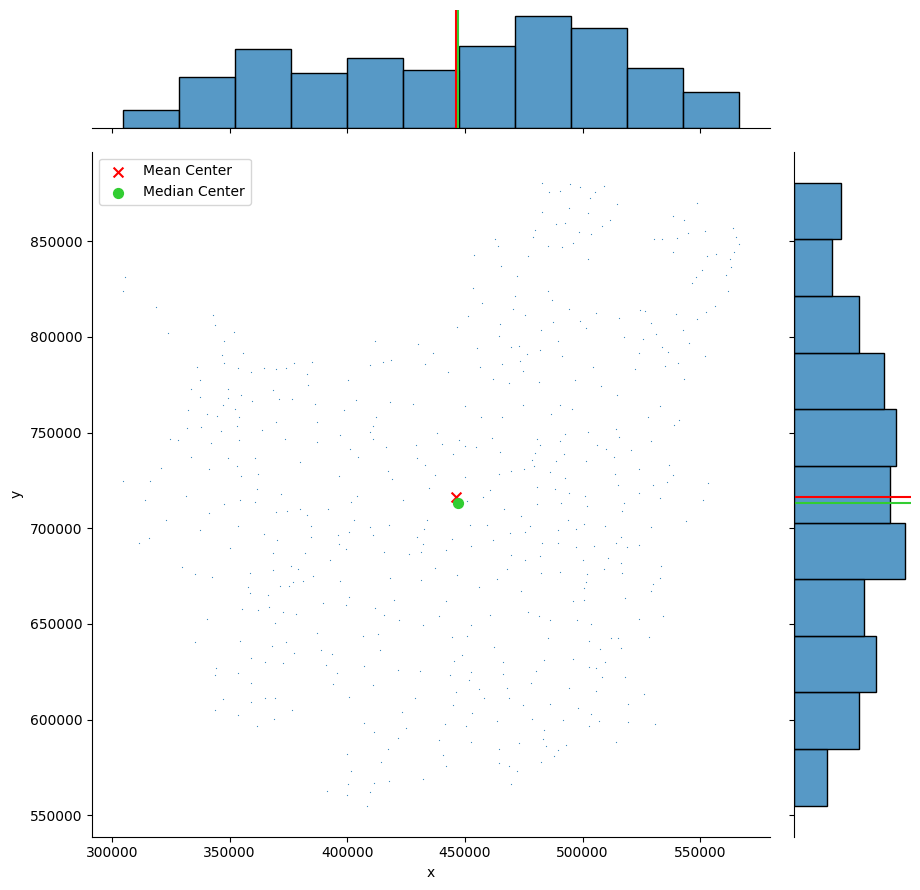

np.float64(103125.2082537115)

In [5]:
joint_axes = sbn.jointplot(x='x', y='y', data=gdf, s=0.75, height=9)

xmin, xmax = joint_axes.ax_joint.get_xlim()
ymin, ymax = joint_axes.ax_joint.get_ylim()

joint_axes.ax_joint.scatter(*mean_center, color='red', marker='x', s=50, label='Mean Center')
joint_axes.ax_marg_x.axvline(mean_center[0], color='red')
joint_axes.ax_marg_y.axhline(mean_center[1], color='red')

joint_axes.ax_joint.scatter(*med_center, color='limegreen', marker='o', s=50, label='Median Center')
joint_axes.ax_marg_x.axvline(med_center[0], color='limegreen')
joint_axes.ax_marg_y.axhline(med_center[1], color='limegreen')
joint_axes.ax_joint.legend()

print(ctx.providers.CartoDB.Positron)

joint_axes.ax_joint.set_xlim(xmin, xmax)
joint_axes.ax_joint.set_ylim(ymin, ymax)
plt.show()

centrography.std_distance(gdf[['x','y']])

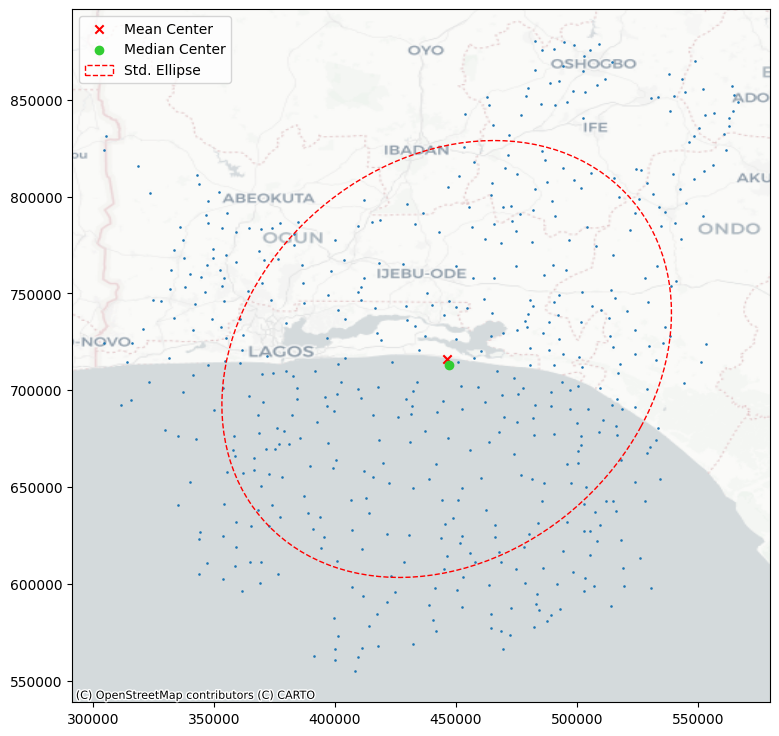

In [6]:
major, minor, rotation = centrography.ellipse(gdf[['x','y']])

# Set up figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot photograph points
ax.scatter(gdf['x'], gdf['y'], s=0.75)
ax.scatter(*mean_center, color='red', marker='x', label='Mean Center')
ax.scatter(*med_center, color='limegreen', marker='o', label='Median Center')

# Construct the standard ellipse using matplotlib
ellipse = Ellipse(xy=mean_center, # center the ellipse on our mean center
                  width=major*2, # centrography.ellipse only gives half the axis
                  height=minor*2, 
                  angle = np.rad2deg(rotation), # Angles for this are in degrees, not radians
                  facecolor='none', 
                  edgecolor='red', linestyle='--',
                  label='Std. Ellipse')
ax.add_patch(ellipse)

ax.legend()
# Display
# Add basemap
ctx.add_basemap(
    ax, 
    source=ctx.providers.CartoDB.Positron
)
plt.show()

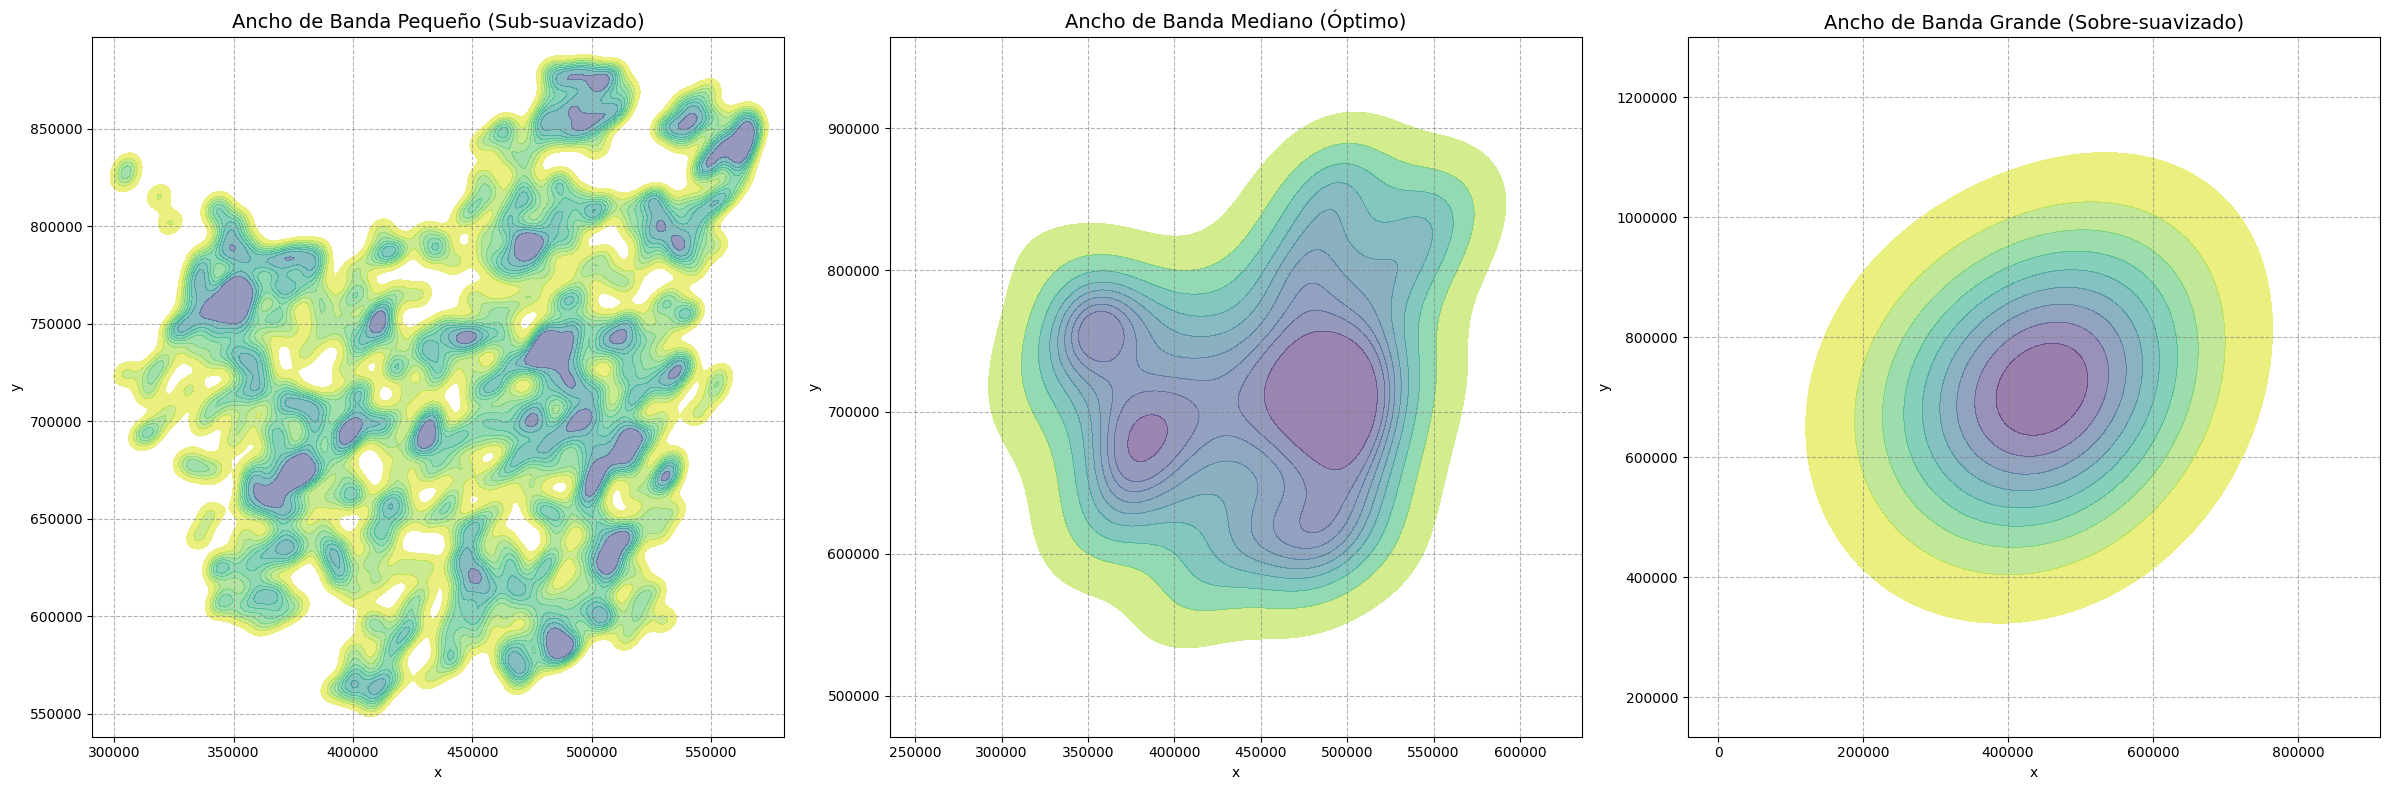

In [7]:
gdf_clean = gdf.dropna(subset=['x', 'y']).copy()
gdf_clean = gdf_clean[(gdf_clean['x'] != 0) & (gdf_clean['y'] != 0)]

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

bandwidths = [0.2, 1.0, 5.0]
titles = ['Ancho de Banda Pequeño (Sub-suavizado)', 'Ancho de Banda Mediano (Óptimo)', 'Ancho de Banda Grande (Sobre-suavizado)']

for ax, bw, title in zip(axes, bandwidths, titles):
    sbn.kdeplot(
        x=gdf_clean['x'],
        y=gdf_clean['y'],
        n_levels=10,
        fill=True,
        alpha=0.55,
        cmap='viridis_r',
        bw_adjust=bw,
        ax=ax
    )
    ax.set_title(title, fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6, color='gray')
    ax.set_axis_on()
    ax.ticklabel_format(style='plain', useOffset=False)

plt.tight_layout()
plt.show()

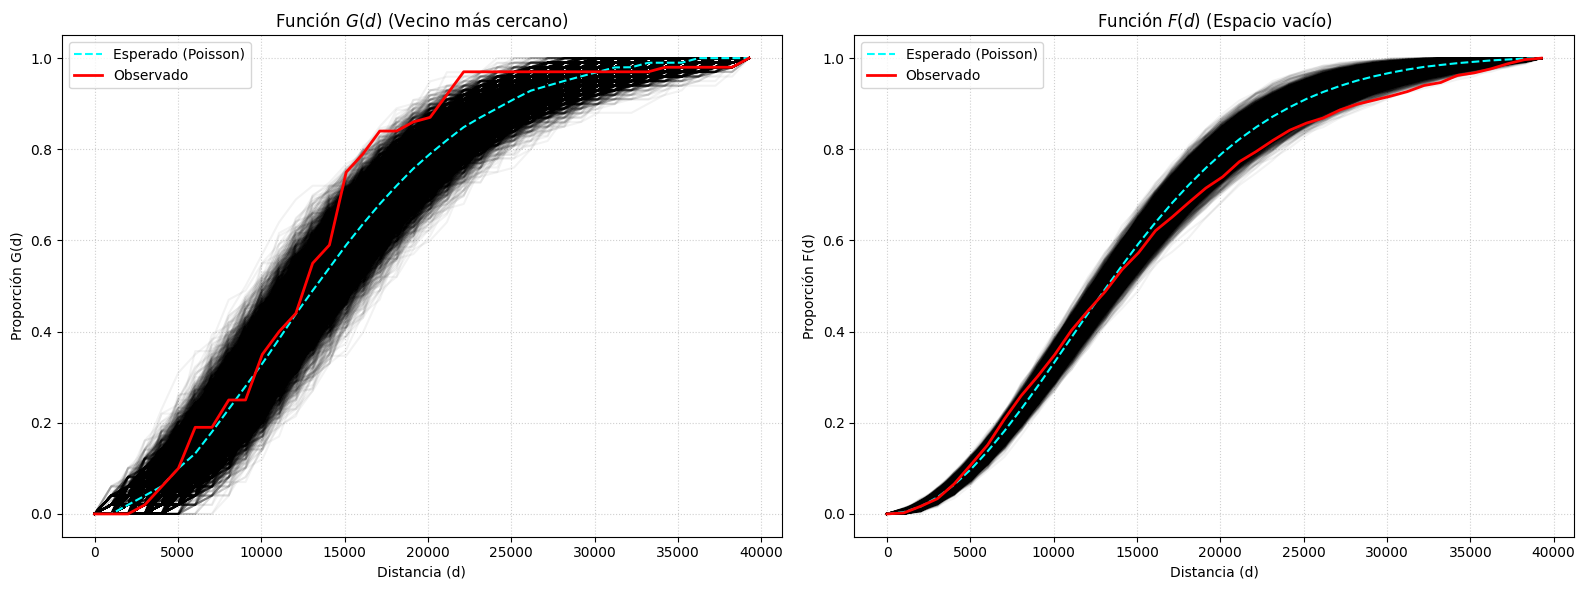

In [8]:
sub_gdf = gdf.dropna(subset=['x', 'y']).sample(n=100)
coordinates = sub_gdf[['x', 'y']].values

g_res = g_test(coordinates, support=40, keep_simulations=True)
f_res = f_test(coordinates, support=40, keep_simulations=True)

f, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].plot(g_res.support, g_res.simulations.T, color='k', alpha=.05)
ax[0].plot(g_res.support, np.median(g_res.simulations, axis=0), color='cyan', linestyle='--', label='Esperado (Poisson)')
ax[0].plot(g_res.support, g_res.statistic, label='Observado', color='red', linewidth=2)
ax[0].set_xlabel('Distancia (d)')
ax[0].set_ylabel('Proporción G(d)')
ax[0].set_title(r"Función $G(d)$ (Vecino más cercano)")
ax[0].legend()
ax[0].grid(True, linestyle=':', alpha=0.6)

ax[1].plot(f_res.support, f_res.simulations.T, color='k', alpha=.05)
ax[1].plot(f_res.support, np.median(f_res.simulations, axis=0), color='cyan', linestyle='--', label='Esperado (Poisson)')
ax[1].plot(f_res.support, f_res.statistic, label='Observado', color='red', linewidth=2)
ax[1].set_xlabel('Distancia (d)')
ax[1].set_ylabel('Proporción F(d)')
ax[1].set_title(r"Función $F(d)$ (Espacio vacío)")
ax[1].legend()
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

--------------------------------------------------
Parámetros: eps = 10000, min_samples = 5
Número de clusters encontrados: 28
Porcentaje de puntos clasificados como ruido: 50.19%
--------------------------------------------------
Parámetros: eps = 15000, min_samples = 10
Número de clusters encontrados: 12
Porcentaje de puntos clasificados como ruido: 48.48%
--------------------------------------------------
Parámetros: eps = 20000, min_samples = 15
Número de clusters encontrados: 10
Porcentaje de puntos clasificados como ruido: 33.65%


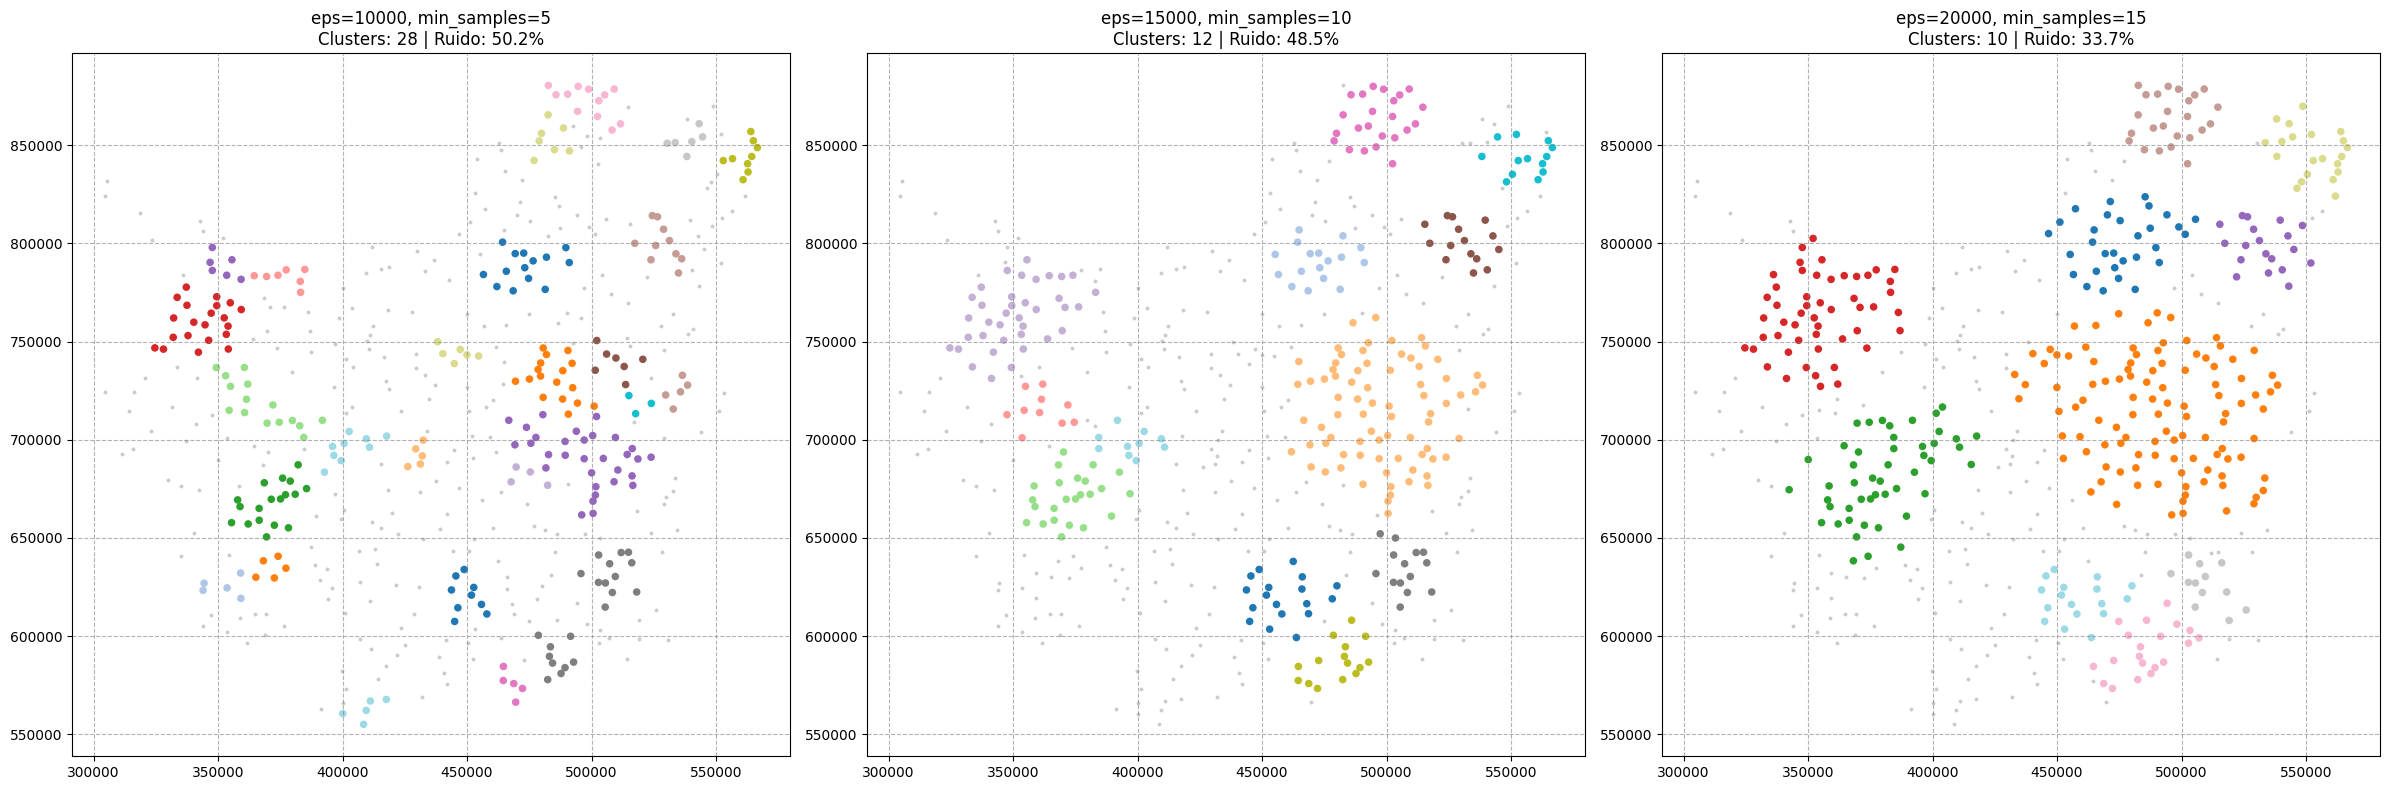

In [9]:
combinaciones = [
    {"eps": 10000, "min_samples": 5},
    {"eps": 15000, "min_samples": 10},
    {"eps": 20000, "min_samples": 15}
]

gdf_clean = gdf.dropna(subset=['x', 'y']).copy()

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, param in zip(axes, combinaciones):
    clusterer = DBSCAN(eps=param["eps"], min_samples=param["min_samples"])
    clusterer.fit(gdf_clean[["x", "y"]])
    lbls = clusterer.labels_
    
    n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
    p_ruido = (np.sum(lbls == -1) / len(lbls)) * 100
    
    print("-" * 50)
    print(f"Parámetros: eps = {param['eps']}, min_samples = {param['min_samples']}")
    print(f"Número de clusters encontrados: {n_clusters}")
    print(f"Porcentaje de puntos clasificados como ruido: {p_ruido:.2f}%")
    
    noise = gdf_clean.loc[lbls == -1, ['x', 'y']]
    ax.scatter(noise['x'], noise['y'], c='grey', s=8, linewidth=0, label='Ruido', alpha=0.4)
    
    clustered_pnts = gdf_clean.loc[lbls != -1]
    lbls_clustered = lbls[lbls != -1]
    
    ax.scatter(
        clustered_pnts['x'], 
        clustered_pnts['y'], 
        c=lbls_clustered, 
        cmap='tab20', 
        s=30, 
        linewidth=0
    )
    
    ax.grid(True, linestyle='--', alpha=0.6, color='gray')
    ax.set_axis_on()
    ax.ticklabel_format(style='plain', useOffset=False)
    ax.set_title(f"eps={param['eps']}, min_samples={param['min_samples']}\nClusters: {n_clusters} | Ruido: {p_ruido:.1f}%", fontsize=12)

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                  y_log   R-squared:                       0.499
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     173.6
Date:                Sun, 31 May 2026   Prob (F-statistic):           4.62e-78
Time:                        16:20:54   Log-Likelihood:                -800.35
No. Observations:                 526   AIC:                             1609.
Df Residuals:                     522   BIC:                             1626.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8396      0.048     37.931      0.0

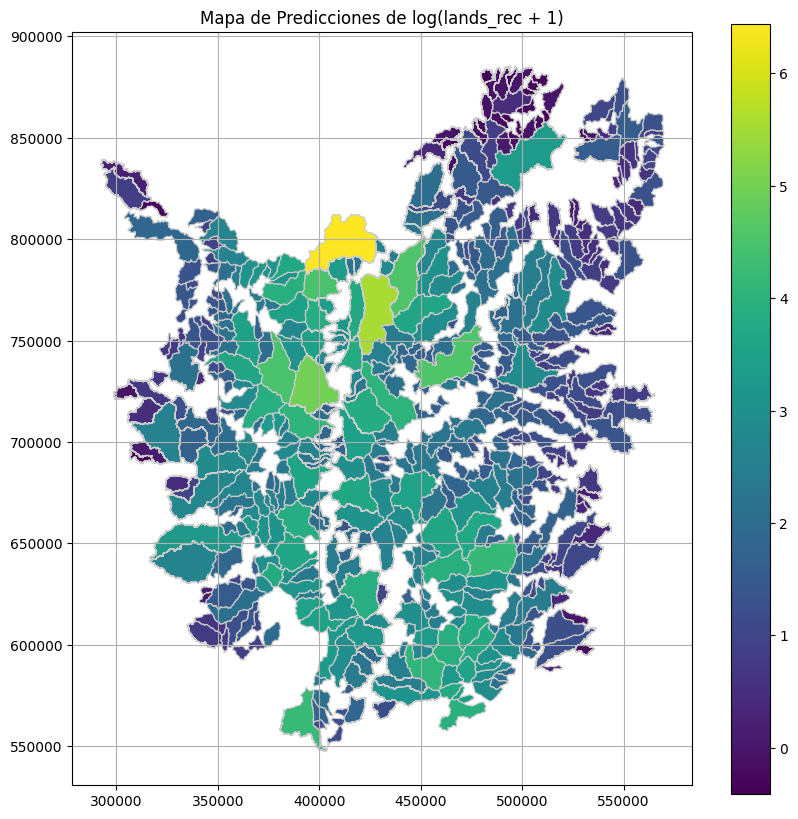

In [10]:
gdf["y_log"] = np.log(gdf['lands_rec'] + 1)
var = ['area', 'elev_mean', 'rel_mean']

# Escalar variables
st = StandardScaler()
X_scaled = st.fit_transform(gdf[var])

# Añadir una constante para el término de intercepción en el modelo
X = sm.add_constant(X_scaled)
y = gdf['y_log']

# Entrenar el modelo de regresión lineal
model = sm.OLS(y, X).fit()

# Imprimir un resumen del modelo
print(model.summary())

# Obtener las predicciones
y_pred = model.predict(X)

# Añadir las predicciones al GeoDataFrame
gdf['y_pred'] = y_pred

# Graficar el mapa con los valores de predicción
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='y_pred', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Mapa de Predicciones de log(lands_rec + 1)')
ax.grid()
plt.show()

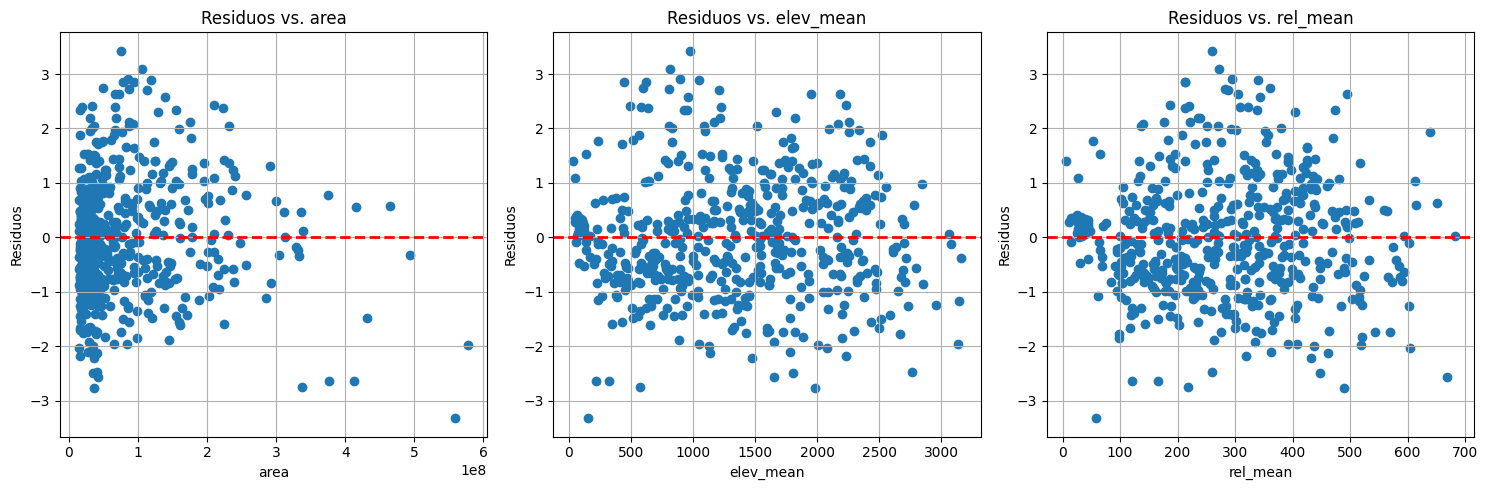

In [11]:
# Calcular los residuos
residuals = y - y_pred

# Crear las figuras scatter para comparar los residuos con cada variable X
plt.figure(figsize=(15, 5))

for i, variable in enumerate(var):
    plt.subplot(1, 3, i + 1)
    plt.scatter(gdf[variable], residuals)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.xlabel(variable)
    plt.ylabel('Residuos')
    plt.title(f'Residuos vs. {variable}')
    plt.grid(True)

plt.tight_layout()
plt.show()

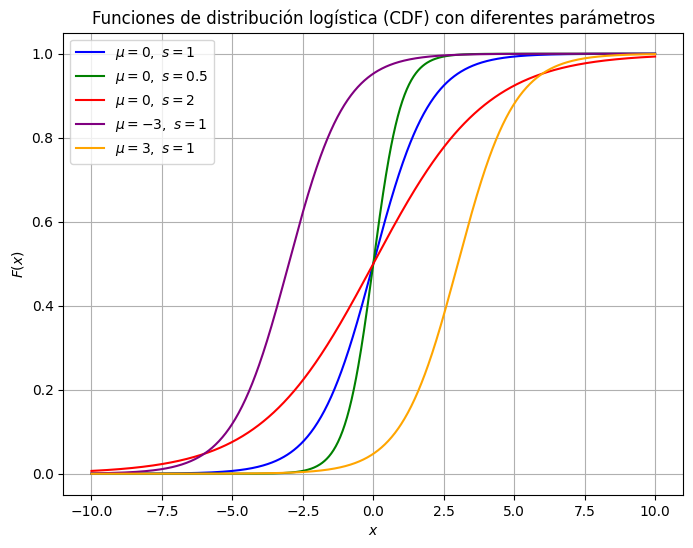

Optimization terminated successfully.
         Current function value: 0.456092
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  500
Model:                          Logit   Df Residuals:                      497
Method:                           MLE   Df Model:                            2
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.2995
Time:                        16:20:58   Log-Likelihood:                -228.05
converged:                       True   LL-Null:                       -325.54
Covariance Type:            nonrobust   LLR p-value:                 4.555e-43
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2504      0.153     -1.638      0.101      -0.550       0.049
x1             1.6643      0.

In [12]:

# Rango de valores de x
x = np.linspace(-10, 10, 1000)

# Conjuntos de parámetros (mu, s)
param_sets = [
    (0, 1),     # estándar
    (0, 0.5),   # más empinada
    (0, 2),     # más dispersa
    (-3, 1),    # desplazada a la izquierda
    (3, 1),     # desplazada a la derecha
]

# Colores para la visualización
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Graficar CDF para cada conjunto de parámetros
plt.figure(figsize=(8, 6))
for (mu, s), color in zip(param_sets, colors):
    y = logistic.cdf(x, loc=mu, scale=s)
    plt.plot(x, y, label=f'$\mu={mu},\ s={s}$', color=color)

plt.title("Funciones de distribución logística (CDF) con diferentes parámetros")
plt.xlabel("$x$")
plt.ylabel("$F(x)$")
plt.legend()
plt.grid(True)
plt.show()

np.random.seed(0)
n = 500

# Covariables
x1 = np.random.normal(0, 1, n)
x2 = np.random.binomial(1, 0.5, n)

# Coeficientes verdaderos
beta_0 = -0.5
beta_1 = 2.0
beta_2 = -1.0

# Probabilidad con función logística
lin_pred = beta_0 + beta_1 * x1 + beta_2 * x2
p = 1 / (1 + np.exp(-lin_pred))

# Variable respuesta binaria
y = np.random.binomial(1, p)

# DataFrame
df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})

X = sm.add_constant(df[['x1', 'x2']])  # añade la constante (intercepto)
y = df['y']

# Ajuste del modelo
modelo = sm.Logit(y, X).fit()

print(modelo.summary())

In [13]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

# Cargar datos
gdf = gpd.read_file("https://github.com/edieraristizabal/ModeloMultinivel/raw/refs/heads/main/DATA/df_catchments_spatial.gpkg")

# Preparar datos para regresión logística
gdf['landslide'] = np.where(gdf['lands_rec'] >= 1, 1, 0)
var = ['area', 'elev_mean', 'rel_mean']
y = gdf['landslide']

# Escalar variables independientes
st = StandardScaler()
X_scaled = st.fit_transform(gdf[var])

# Añadir una constante para el término de intercepción
X = sm.add_constant(X_scaled)

# Entrenar el modelo de regresión logística
model = sm.Logit(y, X).fit()

# Imprimir un resumen del modelo de regresión logística
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.377649
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              landslide   No. Observations:                  526
Model:                          Logit   Df Residuals:                      522
Method:                           MLE   Df Model:                            3
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.3566
Time:                        16:22:07   Log-Likelihood:                -198.64
converged:                       True   LL-Null:                       -308.74
Covariance Type:            nonrobust   LLR p-value:                 1.815e-47
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6657      0.162     10.271      0.000       1.348       1.984
x1             0.5881      0.

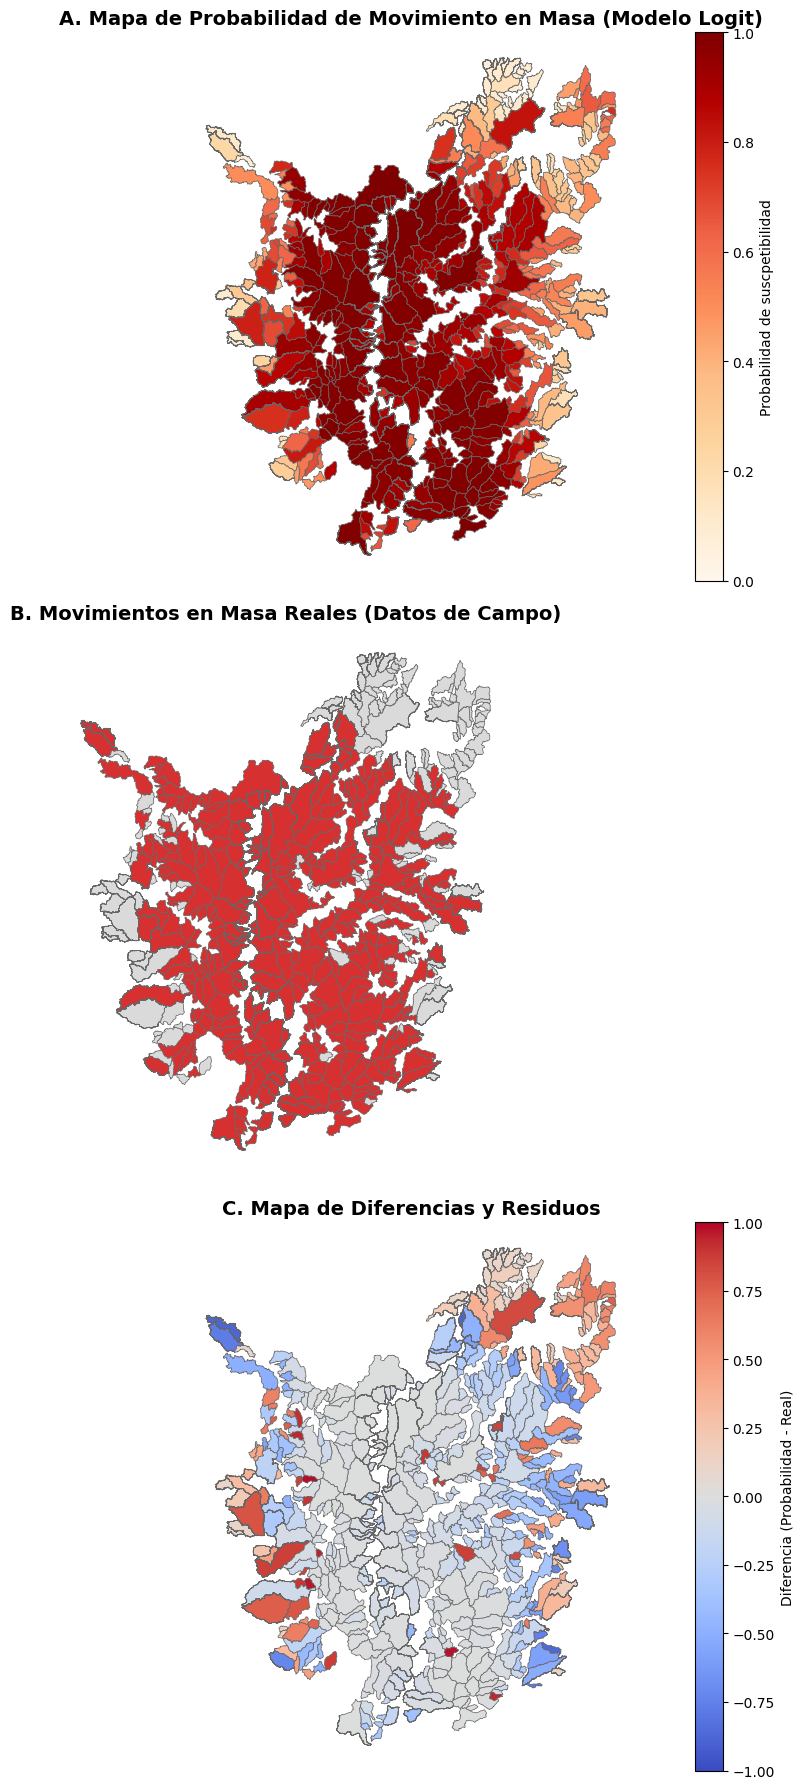

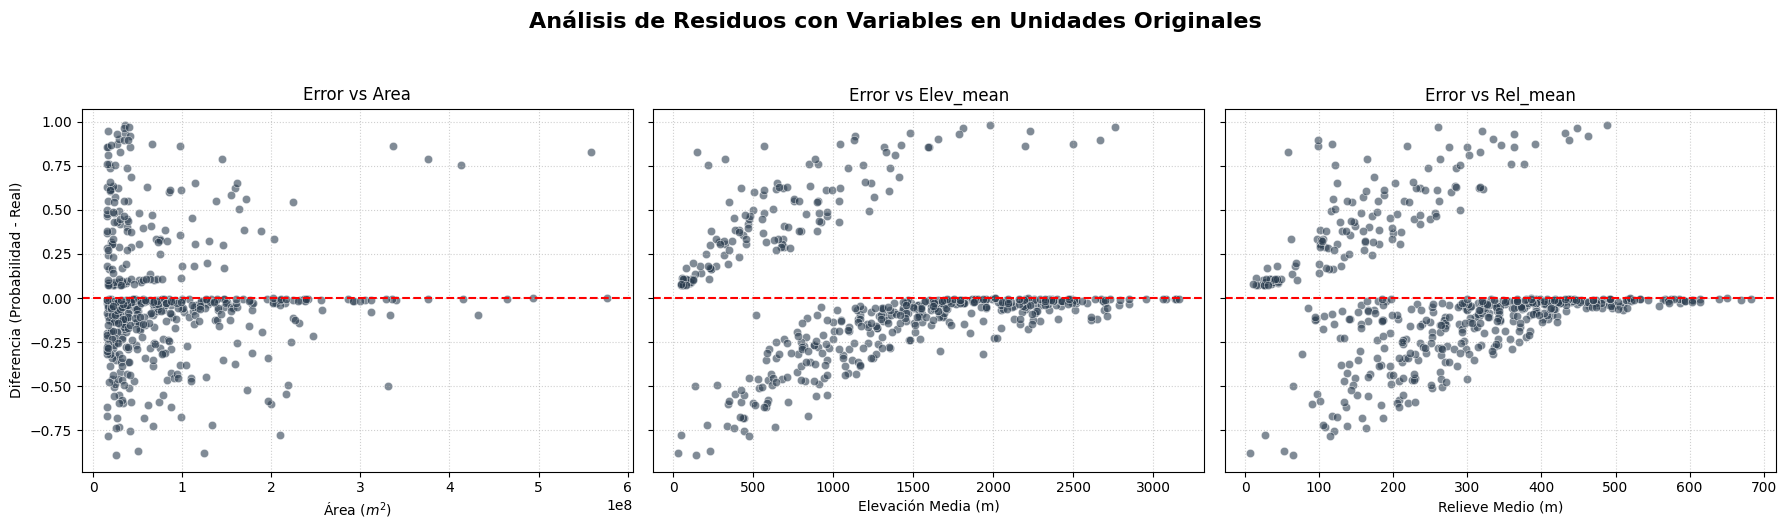

In [14]:
# =============================================================================
# 1. PREDICCIONES Y CÁLCULO DE DIFERENCIAS
# =============================================================================
# Obtener las predicciones en términos de probabilidad
y_prob = model.predict(X)

# Añadir las probabilidades al GeoDataFrame
gdf['probability_landslide'] = y_prob

# Añadir los datos reales para graficar (como tipo string para leyenda categórica)
gdf['real_landslide'] = y.astype(str).replace({'0': 'No Deslizamiento', '1': 'Deslizamiento'})

# Calcular la diferencia (Residuo): Probabilidad - Real
# Valores cercanos a  1: El modelo predijo alta probabilidad pero NO hubo deslizamiento (Falso Positivo)
# Valores cercanos a -1: El modelo predijo baja probabilidad pero SÍ hubo deslizamiento (Falsos Negativo)
gdf['prediction_error'] = gdf['probability_landslide'] - y

# =============================================================================
# 2. GENERACIÓN DE LOS TRES MAPAS COMPARATIVOS
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# ---- MAPA 1: Probabilidades del Modelo ----
gdf.plot(
    column='probability_landslide', 
    cmap='OrRd', 
    linewidth=0.5, 
    ax=axes[0], 
    edgecolor='0.4', 
    legend=True, 
    vmin=0, 
    vmax=1,
    legend_kwds={'label': "Probabilidad de suscpetibilidad"}
)
axes[0].set_title('A. Mapa de Probabilidad de Movimiento en Masa (Modelo Logit)', fontsize=14, fontweight='bold')
axes[0].set_axis_off()

# ---- MAPA 2: Eventos Reales ----
# Usamos un mapa de colores cualitativo personalizado (Gris para 0, Rojo para 1)
color_dict = {'No Deslizamiento': '#dadada', 'Deslizamiento': '#d63031'}
gdf.plot(
    column='real_landslide', 
    linewidth=0.5, 
    ax=axes[1], 
    edgecolor='0.4', 
    legend=True,
    color=[color_dict[val] for val in gdf['real_landslide']]
)
axes[1].set_title('B. Movimientos en Masa Reales (Datos de Campo)', fontsize=14, fontweight='bold')
axes[1].set_axis_off()

# ---- MAPA 3: Mapa de Diferencias (Errores) ----
# Usamos un mapa divergente 'seismic' o 'coolwarm' donde el 0 (predicción perfecta) es blanco
gdf.plot(
    column='prediction_error', 
    cmap='coolwarm', 
    linewidth=0.5, 
    ax=axes[2], 
    edgecolor='0.4', 
    legend=True, 
    vmin=-1, 
    vmax=1,
    legend_kwds={'label': "Diferencia (Probabilidad - Real)"}
)
axes[2].set_title('C. Mapa de Diferencias y Residuos', fontsize=14, fontweight='bold')
axes[2].set_axis_off()

# Ajustar diseño para que no se traslapen
plt.tight_layout()
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# 1. PREPARACIÓN DE LAS VARIABLES EN UNIDADES ORIGINALES
# =============================================================================
# Usamos las columnas originales del GeoDataFrame (sin la transformación StandardScaler)
variables_originales = ['area', 'elev_mean', 'rel_mean']
nombres_ejes_x = ['Área ($m^2$)', 'Elevación Media (m)', 'Relieve Medio (m)']

# =============================================================================
# 2. GENERACIÓN DE LOS SCATTER PLOTS CON UNIDADES ORIGINALES
# =============================================================================
# Creamos una fila con 3 gráficos independientes que comparten el eje Y
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, var_name in enumerate(variables_originales):
    # Graficar la dispersión usando los valores reales en X
    sns.scatterplot(
        data=gdf, 
        x=var_name, 
        y='prediction_error', 
        alpha=0.6, 
        ax=axes[i],
        color='#2c3e50'
    )
    
    # Línea de referencia en 0 (Predicción perfecta)
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Predicción Perfecta')
    
    # Personalización de títulos y etiquetas con sus unidades reales
    axes[i].set_title(f'Error vs {var_name.capitalize()}')
    axes[i].set_xlabel(nombres_ejes_x[i])
    
    # Solo colocamos la etiqueta del eje Y en el primer gráfico para evitar redundancia
    if i == 0:
        axes[i].set_ylabel('Diferencia (Probabilidad - Real)')
        
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Análisis de Residuos con Variables en Unidades Originales', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

                 Generalized Linear Model Regression Results                  
Dep. Variable:              lands_rec   No. Observations:                  526
Model:                            GLM   Df Residuals:                      523
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6974.2
Date:                Sun, 31 May 2026   Deviance:                       12334.
Time:                        16:23:24   Pearson chi2:                 1.79e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -15.5307      0.013  -1210.076      0.0

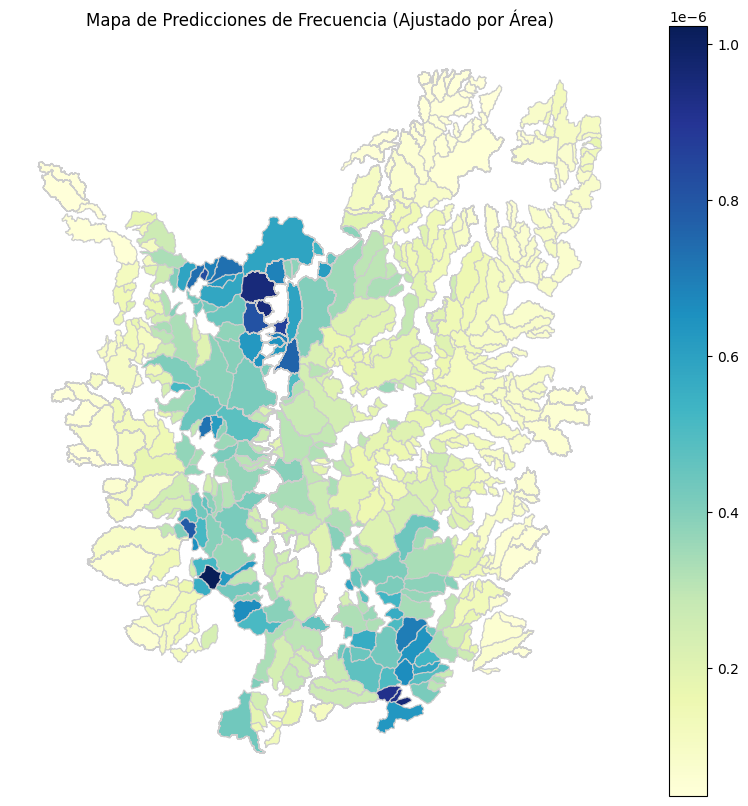

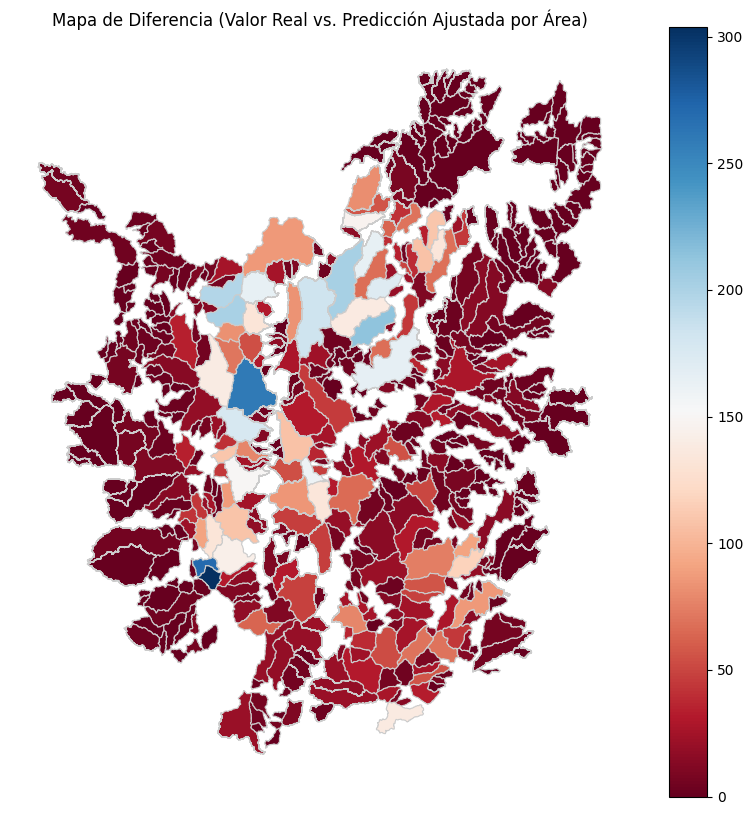

In [15]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
from sklearn.preprocessing import StandardScaler

gdf = gpd.read_file("https://github.com/edieraristizabal/ModeloMultinivel/raw/refs/heads/main/DATA/df_catchments_spatial.gpkg")

# Preparar datos para regresión de Poisson con offset por área
y = gdf['lands_rec']
var = ['elev_mean', 'rel_mean']  # No incluimos 'area' como predictor directamente ahora
exposure = np.log(gdf['area'])  # Logaritmo del área como medida de exposición

# Escalar variables independientes (excepto el área que se usa como offset)
st = StandardScaler()
X_scaled = st.fit_transform(gdf[var])

# Añadir una constante para el término de intercepción
X = sm.add_constant(X_scaled)

# Entrenar el modelo de regresión de Poisson con offset
poisson_model_offset = GLM(y, X, family=families.Poisson(), offset=exposure).fit()

# Imprimir un resumen del modelo de regresión de Poisson con offset
print(poisson_model_offset.summary())

# Obtener las predicciones de frecuencia (ahora representan la frecuencia ajustada por el área)
y_pred_freq_offset = poisson_model_offset.predict(X)

# Añadir las predicciones al GeoDataFrame
gdf['predicted_lands_rec_offset'] = y_pred_freq_offset

# Calcular la diferencia entre el valor real y la predicción con offset
gdf['difference_lands_rec_offset'] = gdf['lands_rec'] - gdf['predicted_lands_rec_offset']

# Graficar el mapa con los valores de predicción de frecuencia ajustados por área
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='predicted_lands_rec_offset', cmap='YlGnBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Mapa de Predicciones de Frecuencia (Ajustado por Área)')
ax.set_axis_off()
plt.show()

# Graficar el mapa con la diferencia entre el valor real y la predicción ajustada por área
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='difference_lands_rec_offset', cmap='RdBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Mapa de Diferencia (Valor Real vs. Predicción Ajustada por Área)')
ax.set_axis_off()
plt.show()

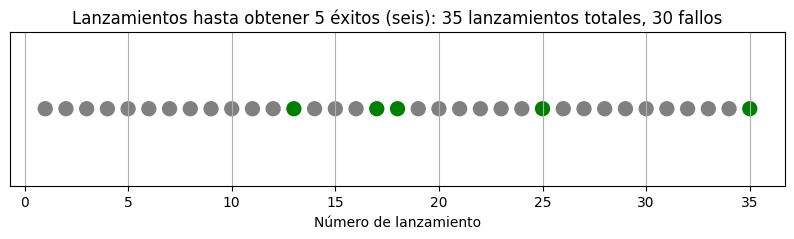

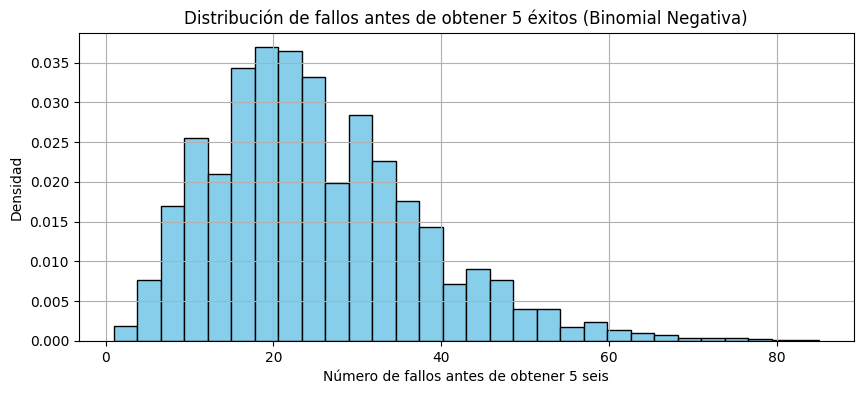

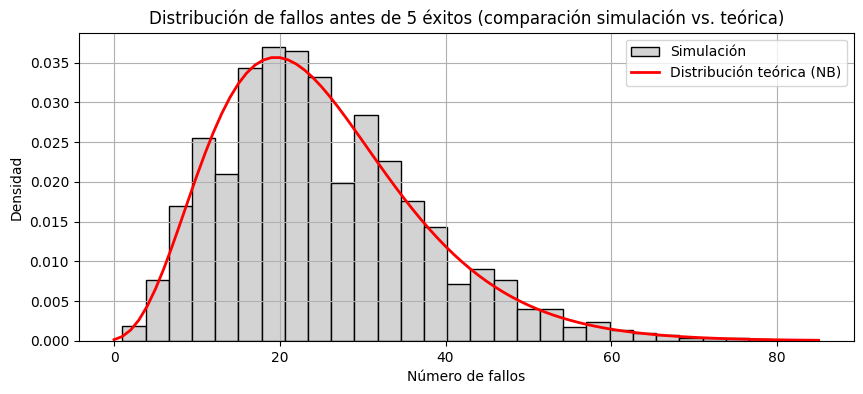

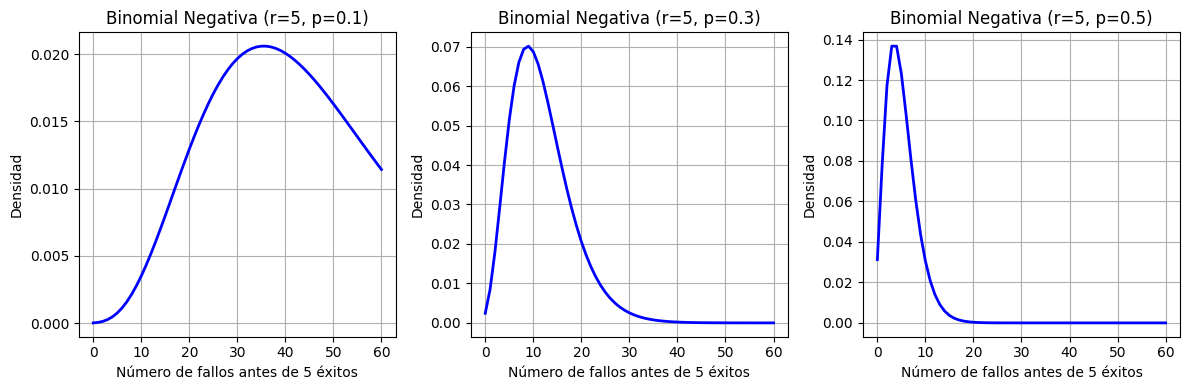

In [16]:
# Parámetros del experimento
p = 1/6  # Probabilidad de éxito (sacar un 6)
r = 5    # Número de éxitos deseados

np.random.seed(42)

# Simular lanzamientos hasta obtener r éxitos
lanzamientos = []
exitos = 0

while exitos < r:
    dado = np.random.randint(1, 7)
    lanzamientos.append(dado)
    if dado == 6:
        exitos += 1

# Convertir a array
lanzamientos = np.array(lanzamientos)
n_lanzamientos = len(lanzamientos)
fallos = n_lanzamientos - r

# Visualizar la secuencia
plt.figure(figsize=(10, 2))
colors = ['green' if x == 6 else 'gray' for x in lanzamientos]
plt.scatter(range(1, n_lanzamientos + 1), [1]*n_lanzamientos, c=colors, s=100)
plt.yticks([])
plt.xlabel("Número de lanzamiento")
plt.title(f"Lanzamientos hasta obtener {r} éxitos (seis): {n_lanzamientos} lanzamientos totales, {fallos} fallos")
plt.grid(True, axis='x')
plt.show()

# Repetir el experimento muchas veces
n_repeticiones = 10000
resultados = []

for _ in range(n_repeticiones):
    exitos = 0
    lanzamientos = 0
    while exitos < r:
        dado = np.random.randint(1, 7)
        lanzamientos += 1
        if dado == 6:
            exitos += 1
    fallos = lanzamientos - r
    resultados.append(fallos)

# Visualizar la distribución de fallos hasta obtener r éxitos
plt.figure(figsize=(10, 4))
plt.hist(resultados, bins=30, color='skyblue', edgecolor='black', density=True)
plt.title(f"Distribución de fallos antes de obtener {r} éxitos (Binomial Negativa)")
plt.xlabel("Número de fallos antes de obtener 5 seis")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

from scipy.stats import nbinom

# Valores posibles de fallos
x_vals = np.arange(0, max(resultados)+1)

# Parámetros de la binomial negativa:
# r = número de éxitos deseados
# p = probabilidad de éxito por ensayo
# En scipy, nbinom(k; r, p) da la probabilidad de k fallos antes de r éxitos
pmf_vals = nbinom.pmf(x_vals, n=r, p=p)

# Gráfico comparativo
plt.figure(figsize=(10, 4))
plt.hist(resultados, bins=30, color='lightgray', edgecolor='black', density=True, label="Simulación")
plt.plot(x_vals, pmf_vals, 'r-', lw=2, label="Distribución teórica (NB)")
plt.title(f"Distribución de fallos antes de {r} éxitos (comparación simulación vs. teórica)")
plt.xlabel("Número de fallos")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.show()

# Repetir el análisis con distintos valores de p y r fijos (5)
ps = [0.1, 0.3, 0.5]
r = 5
max_fallos = 60

plt.figure(figsize=(12, 4))
for i, p_val in enumerate(ps):
    x_vals = np.arange(0, max_fallos + 1)
    pmf_vals = nbinom.pmf(x_vals, n=r, p=p_val)

    plt.subplot(1, 3, i + 1)
    plt.plot(x_vals, pmf_vals, 'b-', lw=2)
    plt.title(f"Binomial Negativa (r={r}, p={p_val})")
    plt.xlabel("Número de fallos antes de 5 éxitos")
    plt.ylabel("Densidad")
    plt.grid(True)

plt.tight_layout()
plt.show()

c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:              lands_rec   No. Observations:                  526
Model:                            GLM   Df Residuals:                      523
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1906.2
Date:                Sun, 31 May 2026   Deviance:                       1177.7
Time:                        16:24:41   Pearson chi2:                 1.91e+03
No. Iterations:                    11   Pseudo R-squ. (CS):             0.5729
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5650      0.047     54.976      0.0

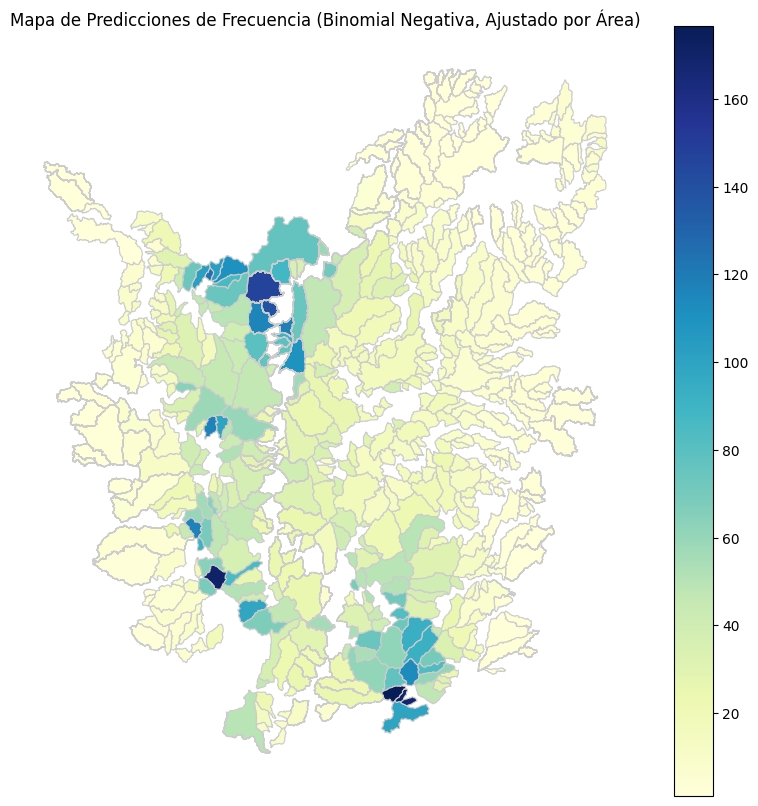

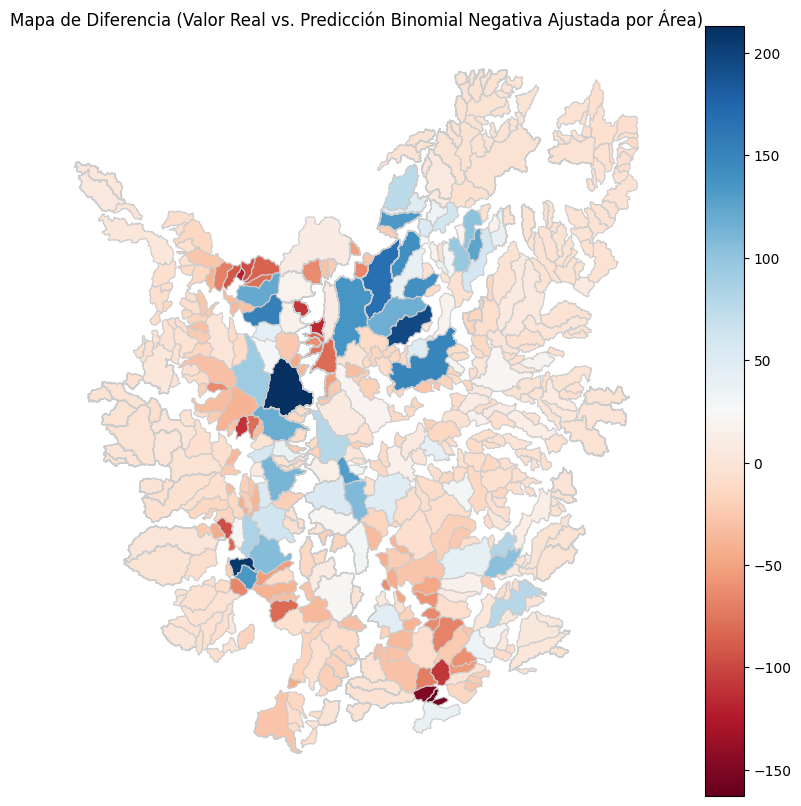

In [17]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
from sklearn.preprocessing import StandardScaler

gdf = gpd.read_file("https://github.com/edieraristizabal/ModeloMultinivel/raw/refs/heads/main/DATA/df_catchments_spatial.gpkg")

# Preparar datos para regresión binomial negativa con offset por área
y = gdf['lands_rec']
var = ['elev_mean', 'rel_mean']  # No incluimos 'area' como predictor directamente ahora
exposure = np.log(gdf['area'])  # Logaritmo del área como medida de exposición

# Escalar variables independientes (excepto el área que se usa como offset)
st = StandardScaler()
X_scaled = st.fit_transform(gdf[var])

# Añadir una constante para el término de intercepción
X = sm.add_constant(X_scaled)

# Entrenar el modelo de regresión binomial negativa con offset
negative_binomial_model_offset = GLM(y, X, family=families.NegativeBinomial()).fit()

# Imprimir un resumen del modelo de regresión binomial negativa con offset
print(negative_binomial_model_offset.summary())

# Obtener las predicciones de frecuencia (ahora representan la frecuencia ajustada por el área)
y_pred_freq_offset_nb = negative_binomial_model_offset.predict(X)

# Añadir las predicciones al GeoDataFrame
gdf['predicted_lands_rec_offset_nb'] = y_pred_freq_offset_nb

# Calcular la diferencia entre el valor real y la predicción con offset (Binomial Negativa)
gdf['difference_lands_rec_offset_nb'] = gdf['lands_rec'] - gdf['predicted_lands_rec_offset_nb']

# Graficar el mapa con los valores de predicción de frecuencia ajustados por área (Binomial Negativa)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='predicted_lands_rec_offset_nb', cmap='YlGnBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Mapa de Predicciones de Frecuencia (Binomial Negativa, Ajustado por Área)')
ax.set_axis_off()
plt.show()

# Graficar el mapa con la diferencia entre el valor real y la predicción ajustada por área (Binomial Negativa)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='difference_lands_rec_offset_nb', cmap='RdBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Mapa de Diferencia (Valor Real vs. Predicción Binomial Negativa Ajustada por Área)')
ax.set_axis_off()
plt.show()

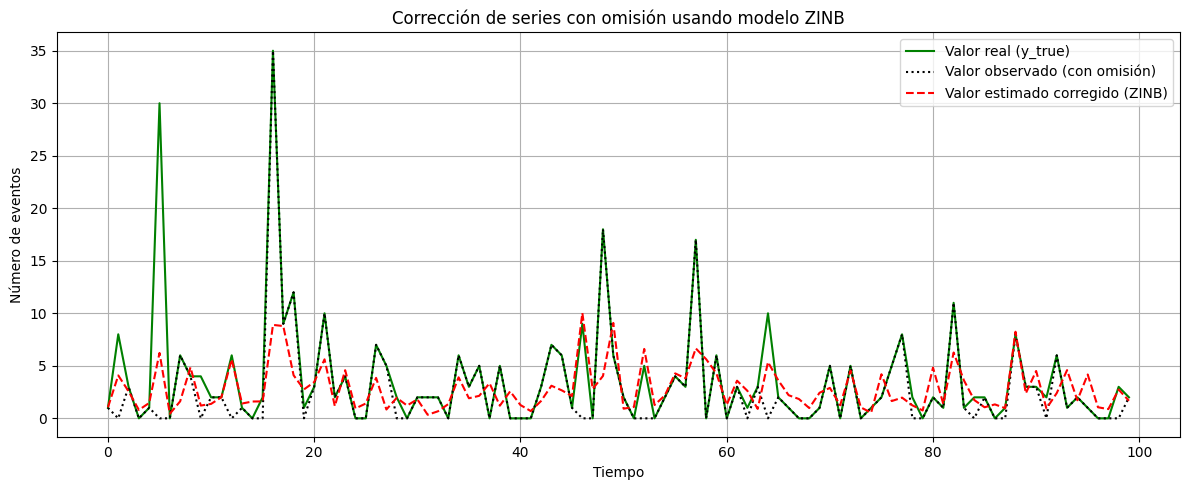

In [18]:
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

# 1. Simular datos reales
np.random.seed(123)
n = 100
tiempo = np.arange(n)  # ejemplo: 100 años o meses
x = np.random.normal(0, 1, n)  # predictor temporal (puede ser SPI, pendiente promedio, etc.)

# Modelo real
beta_0 = 1.0
beta_1 = 0.8
theta = 2.0
mu = np.exp(beta_0 + beta_1 * x)
from scipy.stats import nbinom
p = theta / (theta + mu)
r = theta
y_true = nbinom.rvs(r, p)

# 2. Introducir falsos ceros (subregistro): 25% de los y_true > 0 se vuelven 0
y_obs = y_true.copy()
mask = (y_true > 0) & (np.random.rand(n) < 0.25)
y_obs[mask] = 0

# 3. Preparar datos
df = pd.DataFrame({
    "tiempo": tiempo,
    "x": x,
    "y_obs": y_obs,
    "y_true": y_true,
    "falso_cero": (y_obs == 0) & (y_true > 0)
})

# 4. Ajustar modelo ZINB (modelo de corrección)
exog = sm.add_constant(df["x"])  # incluye intercepto
zinb_model = ZeroInflatedNegativeBinomialP(endog=df["y_obs"], exog=exog, exog_infl=exog, inflation="logit")
zinb_result = zinb_model.fit(method="bfgs", maxiter=100, disp=False)

# 5. Estimar media esperada corregida
df["mu_pred"] = zinb_result.predict()

# 6. Visualizar serie original, observada y corregida
plt.figure(figsize=(12, 5))
plt.plot(df["tiempo"], df["y_true"], label="Valor real (y_true)", color="green")
plt.plot(df["tiempo"], df["y_obs"], label="Valor observado (con omisión)", color="black", linestyle="dotted")
plt.plot(df["tiempo"], df["mu_pred"], label="Valor estimado corregido (ZINB)", color="red", linestyle="--")
plt.xlabel("Tiempo")
plt.ylabel("Número de eventos")
plt.title("Corrección de series con omisión usando modelo ZINB")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Optimization terminated successfully.
         Current function value: 16.416776
         Iterations: 9
         Function evaluations: 12
         Gradient evaluations: 12
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:               lands_rec   No. Observations:                  526
Model:             ZeroInflatedPoisson   Df Residuals:                      523
Method:                            MLE   Df Model:                            2
Date:                 Sun, 31 May 2026   Pseudo R-squ.:                  0.1209
Time:                         16:24:46   Log-Likelihood:                -8635.2
converged:                        True   LL-Null:                       -9823.3
Covariance Type:             nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
inflate_const    -0.9769

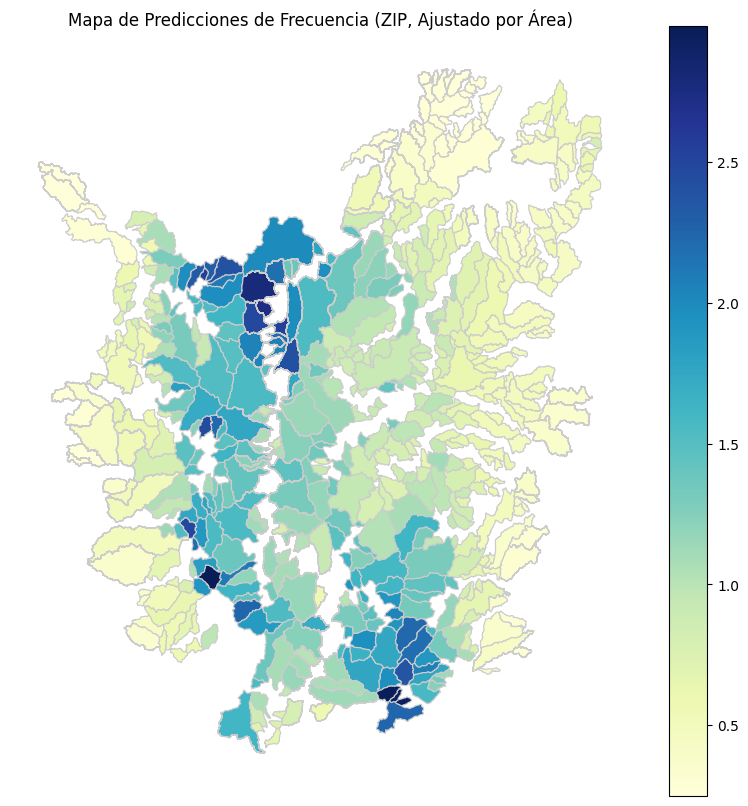

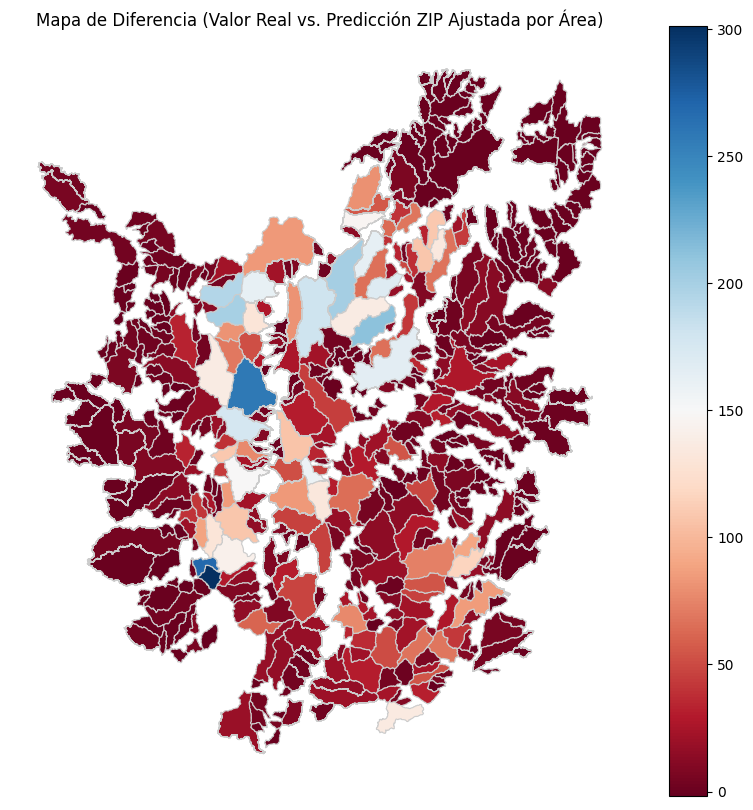

In [19]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson
from sklearn.preprocessing import StandardScaler

# Preparar datos para regresión Zero-Inflated Poisson con offset por área
y = gdf['lands_rec']
var = ['elev_mean', 'rel_mean']  # No incluimos 'area' como predictor directamente ahora
exposure = np.log(gdf['area'])  # Logaritmo del área como medida de exposición

# Escalar variables independientes (excepto el área que se usa como offset)
st = StandardScaler()
X_scaled = st.fit_transform(gdf[var])

# Añadir una constante para el término de intercepción
X = sm.add_constant(X_scaled)

# Entrenar el modelo de regresión Zero-Inflated Poisson con offset
zip_model_offset = ZeroInflatedPoisson(y, X, exposure=exposure).fit()

# Imprimir un resumen del modelo de regresión Zero-Inflated Poisson con offset
print(zip_model_offset.summary())

# Obtener las predicciones de frecuencia
y_pred_freq_offset_zip = zip_model_offset.predict(X)

# Añadir las predicciones al GeoDataFrame
gdf['predicted_lands_rec_offset_zip'] = y_pred_freq_offset_zip

# Calcular la diferencia entre el valor real y la predicción con offset (ZIP)
gdf['difference_lands_rec_offset_zip'] = gdf['lands_rec'] - gdf['predicted_lands_rec_offset_zip']


# Graficar el mapa con los valores de predicción de frecuencia ajustados por área (ZIP)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='predicted_lands_rec_offset_zip', cmap='YlGnBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Mapa de Predicciones de Frecuencia (ZIP, Ajustado por Área)')
ax.set_axis_off()
plt.show()

# Graficar el mapa con la diferencia entre el valor real y la predicción ajustada por área (ZIP)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='difference_lands_rec_offset_zip', cmap='RdBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Mapa de Diferencia (Valor Real vs. Predicción ZIP Ajustada por Área)')
ax.set_axis_off()
plt.show()

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

gdf = gpd.read_file("https://github.com/edieraristizabal/ModeloMultinivel/raw/refs/heads/main/DATA/df_catchments_spatial.gpkg")
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   id                   526 non-null    int64   
 1   Nombre               526 non-null    str     
 2   ID_CUENCA            526 non-null    float64 
 3   cuenca               526 non-null    str     
 4   area                 526 non-null    int64   
 5   elev_mean            526 non-null    float64 
 6   elev_median          526 non-null    float64 
 7   rel_mean             526 non-null    float64 
 8   rel_median           526 non-null    float64 
 9   rainfallAnnual_mean  526 non-null    float64 
 10  Densidad             526 non-null    float64 
 11  hypso_inte           526 non-null    float64 
 12  slope_mean           526 non-null    float64 
 13  kmeans               526 non-null    str     
 14  RainfallDaysmean     526 non-null    float64 
 15  RainfallDaysmed

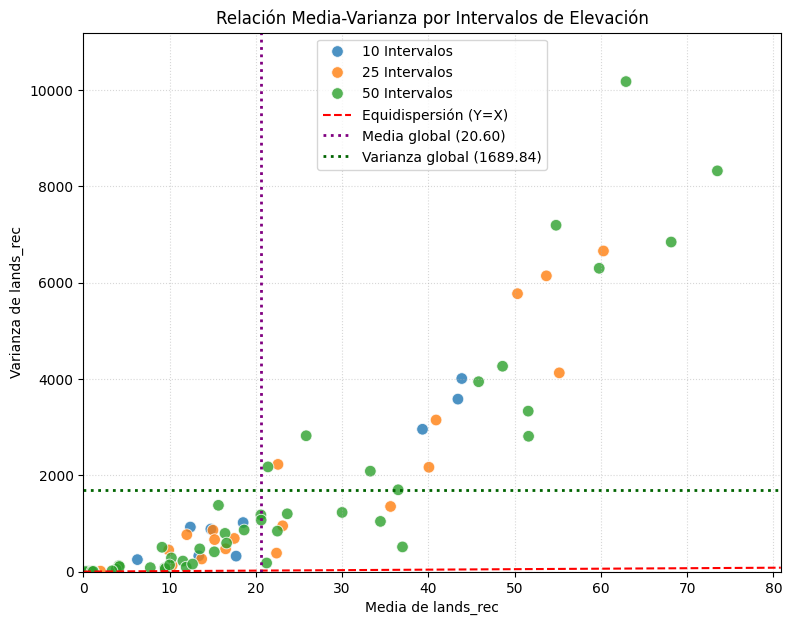

Debido a que se puede observar que la varianza (1689.8361071881227) de los datos es significativamente superior a la media (20.602661596958175), 
es posible concluir que el numero de deslizamientos totales por cuenca cuenta con sobre dispersión. 
Esto puede traducirse como una limitación en la distribución de Poisson donde se subestima la variabilidad de los datos.  
Esto puede ser explicado debido a que se tratan de cuencas a escala regional, encontrando procesos diferentes entre si debido a la variabilidad local de los dichos procesos


In [21]:
#Primer punto de ejercicio GML
#   Selección de distribución: Para el dataset de cuencas, grafica la relación entre la media y la varianza de lands_rec 
#   agrupando por rangos de elev_mean. Si la varianza es mayor que la media, ¿qué problema presenta un modelo de Poisson estándar? 
#   ¿Qué alternativa propondrías?

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

mean_global = gdf['lands_rec'].mean()
var_global = gdf['lands_rec'].var()

intervals = [10, 25, 50]
all_stats = []

for bins in intervals:
    gdf['elev_bin'] = pd.cut(gdf['elev_mean'], bins=bins)
    
    stats = gdf.groupby('elev_bin', observed=False)['lands_rec'].agg(['mean', 'var']).reset_index()
    stats = stats.dropna()
    stats['Cantidad Intervalos'] = f'{bins} Intervalos'
    all_stats.append(stats)

df_res = pd.concat(all_stats, ignore_index=True)

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df_res, x='mean', y='var', hue='Cantidad Intervalos', alpha=0.8, s=70)

max_x = max(df_res['mean'].max(), mean_global) * 1.1
max_y = max(df_res['var'].max(), var_global) * 1.1

plt.plot([0, max_x], [0, max_x], color='red', linestyle='--', label='Equidispersión (Y=X)')

plt.axvline(x=mean_global, color='purple', linestyle=':', linewidth=2, label=f'Media global ({mean_global:.2f})')
plt.axhline(y=var_global, color='darkgreen', linestyle=':', linewidth=2, label=f'Varianza global ({var_global:.2f})')

plt.xlim(0, max_x)
plt.ylim(0, max_y)
plt.xlabel('Media de lands_rec')
plt.ylabel('Varianza de lands_rec')
plt.title('Relación Media-Varianza por Intervalos de Elevación')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

print(f"Debido a que se puede observar que la varianza ({var_global}) de los datos es significativamente superior a la media ({mean_global}), \nes posible concluir que el numero de deslizamientos totales por cuenca cuenta con sobre dispersión. \nEsto puede traducirse como una limitación en la distribución de Poisson donde se subestima la variabilidad de los datos.  \nEsto puede ser explicado debido a que se tratan de cuencas a escala regional, encontrando procesos diferentes entre si debido a la variabilidad local de los dichos procesos")

Optimization terminated successfully.
         Current function value: 0.475294
         Iterations 6

MATRIZ DE CONFUSIÓN (Umbral = 0.5)
                Predicho: Bajo (0)  Predicho: Alto (1)
Real: Bajo (0)                 205                  59
Real: Alto (1)                  67                 195


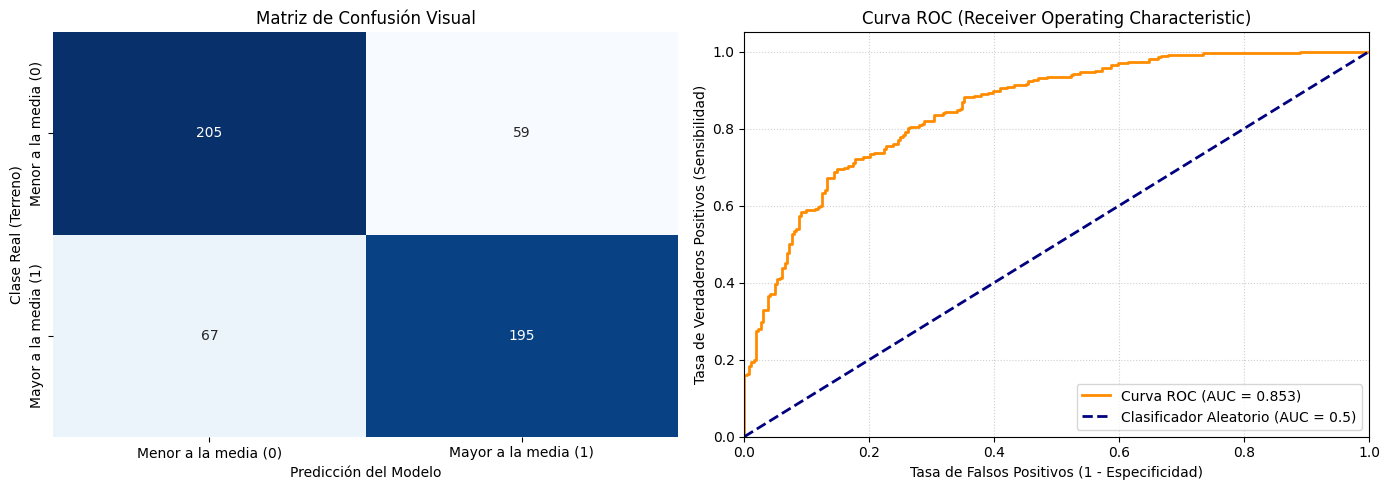


REPORTE FORMAL: COEFICIENTES Y ODDS RATIOS (IC 95%)
           Coeficiente (Beta)  p-valor  Odds Ratio (OR)  OR IC 2.5%  \
const                  0.0326    0.771           1.0332      0.8293   
elev_mean              0.7305    0.000           2.0761      1.6058   
rel_mean               1.0549    0.000           2.8717      2.1692   
area                   0.9352    0.000           2.5477      1.9078   

           OR IC 97.5%  
const           1.2872  
elev_mean       2.6840  
rel_mean        3.8017  
area            3.4023  


In [15]:
import geopandas as gpd
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score 
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns




COLUMNA_DESLIZAMIENTOS = 'lands_rec'  

# Las 3 covariables que definiste (¡asegúrate de que existan exactamente con estos nombres!)
covariables = ['elev_mean', 'rel_mean', 'area']
# ==============================================================================

# 2. Crear la variable binaria desliz_alto basada en la mediana
mediana_desliz = gdf['lands_rec'].median()
gdf['desliz_alto'] = (gdf[COLUMNA_DESLIZAMIENTOS] > mediana_desliz).astype(int)

# 3. Seleccionar las covariables y la variable objetivo
X = gdf[covariables].copy()
y = gdf['desliz_alto']

# Opcional: Eliminar filas con valores nulos (NaN) para evitar fallos en el ajuste
X = X.dropna()
y = y.loc[X.index]

# 4. Estandarizar las covariables
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=covariables, index=X.index)

# Añadir el intercepto requerido por statsmodels
X_scaled = sm.add_constant(X_scaled)

# 5. Ajustar el modelo de Regresión Logística Binaria
modelo = sm.Logit(y, X_scaled).fit()


# CORRECCIÓN: Añadido roc_curve aquí

# A. Matriz de Confusión en Consola
cm = confusion_matrix(y, y_pred)
df_cm = pd.DataFrame(cm, index=['Real: Bajo (0)', 'Real: Alto (1)'], 
                         columns=['Predicho: Bajo (0)', 'Predicho: Alto (1)'])
print("\n" + "="*40)
print("MATRIZ DE CONFUSIÓN (Umbral = 0.5)")
print("="*40)
print(df_cm)
print("="*40)

# B. Gráficos: Curva ROC y Matriz de Confusión Visual
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Matriz de Confusión Estilizada
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False,
            xticklabels=['Menor a la media (0)', 'Mayor a la media (1)'], yticklabels=['Menor a la media (0)', 'Mayor a la media (1)'])
ax[0].set_title('Matriz de Confusión Visual')
ax[0].set_xlabel('Predicción del Modelo')
ax[0].set_ylabel('Clase Real (Terreno)')

# Gráfico 2: Curva AUC - ROC
# ¡Ahora sí funcionará sin NameError!
fpr, tpr, thresholds = roc_curve(y, y_probs)
auc_value = roc_auc_score(y, y_probs)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_value:.3f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax[1].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax[1].set_title('Curva ROC (Receiver Operating Characteristic)')
ax[1].legend(loc="lower right")
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ==============================================================================
# CORRE ESTE BLOQUE PARA OBTENER LOS DATOS EXACTOS DE TU MODELO
# ==============================================================================

print("\n" + "="*80)
print("REPORTE FORMAL: COEFICIENTES Y ODDS RATIOS (IC 95%)")
print("="*80)

# 1. Extraer coeficientes, p-valores e intervalos de confianza del modelo ajustado
df_reporte = pd.DataFrame({
    'Coeficiente (Beta)': modelo.params,
    'p-valor': modelo.pvalues
})

# Añadir Intervalos de Confianza para los coeficientes
int_conf_beta = modelo.conf_int()
df_reporte['IC Beta 2.5%'] = int_conf_beta[0]
df_reporte['IC Beta 97.5%'] = int_conf_beta[1]

# 2. Calcular los Odds Ratios (exponenciando los valores anteriores)
df_reporte['Odds Ratio (OR)'] = np.exp(modelo.params)
df_reporte['OR IC 2.5%'] = np.exp(int_conf_beta[0])
df_reporte['OR IC 97.5%'] = np.exp(int_conf_beta[1])

# Reordenar y redondear las columnas para que sea fácil de leer
columnas_ordenadas = [
    'Coeficiente (Beta)', 'p-valor', 
    'Odds Ratio (OR)', 'OR IC 2.5%', 'OR IC 97.5%'
]

# Mostrar la tabla formateada
print(df_reporte[columnas_ordenadas].round(4))
print("="*80)

c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


COMPARACIÓN DE CRITERIO DE INFORMACIÓN DE AKAIKE (AIC)
Regresión Lineal:     AIC = 5213.64
Regresión de Poisson:  AIC = 15884.06
Binomial Negativa:    AIC = 3620.29


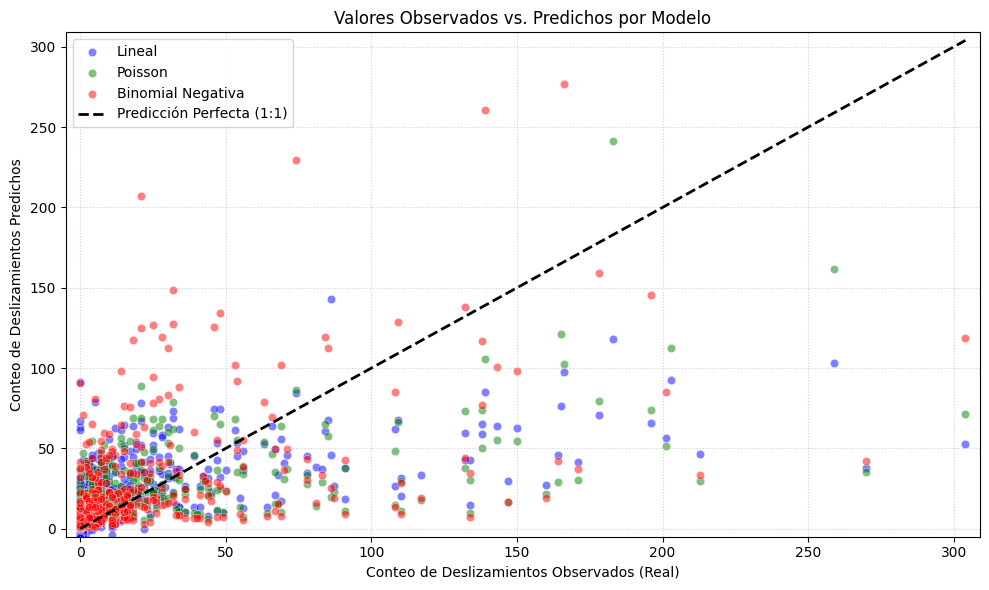

In [10]:
covariables = ['elev_mean', 'rel_mean', 'area']
X = gdf[covariables].dropna()
y = gdf['lands_rec'].loc[X.index]

# Estandarizar covariables
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=covariables, index=X.index)
X_scaled = sm.add_constant(X_scaled)

# ==============================================================================
# AJUSTE DE LOS TRES MODELOS
# ==============================================================================

# (a) Regresión Lineal (Gaussiana)
modelo_lineal = sm.OLS(y, X_scaled).fit()

# (b) Regresión de Poisson
modelo_poisson = sm.GLM(y, X_scaled, family=sm.families.Poisson()).fit()

# (c) Regresión Binomial Negativa (NB2)
modelo_nb = sm.GLM(y, X_scaled, family=sm.families.NegativeBinomial()).fit()

# ==============================================================================
# COMPARACIÓN POR AIC
# ==============================================================================
print("="*50)
print("COMPARACIÓN DE CRITERIO DE INFORMACIÓN DE AKAIKE (AIC)")
print("="*50)
print(f"Regresión Lineal:     AIC = {modelo_lineal.aic:.2f}")
print(f"Regresión de Poisson:  AIC = {modelo_poisson.aic:.2f}")
print(f"Binomial Negativa:    AIC = {modelo_nb.aic:.2f}")
print("="*50)

# ==============================================================================
# PREDICCIONES Y GRÁFICO COMPARATIVO
# ==============================================================================
# Generar predicciones
pred_lineal = modelo_lineal.predict(X_scaled)
pred_poisson = modelo_poisson.predict(X_scaled)
pred_nb = modelo_nb.predict(X_scaled)

# Crear DataFrame de comparación
df_pred = pd.DataFrame({
    'Observado': y,
    'Lineal': pred_lineal,
    'Poisson': pred_poisson,
    'Binomial Negativa': pred_nb
})

# Graficar Valores Observados vs Predichos
plt.figure(figsize=(10, 6))

# Usamos un regplot o scatter plot con línea de tendencia ideal (1:1)
sns.scatterplot(x='Observado', y='Lineal', data=df_pred, color='blue', alpha=0.5, label='Lineal')
sns.scatterplot(x='Observado', y='Poisson', data=df_pred, color='green', alpha=0.5, label='Poisson')
sns.scatterplot(x='Observado', y='Binomial Negativa', data=df_pred, color='red', alpha=0.5, label='Binomial Negativa')

# Línea de referencia 1:1 (Predicción Perfecta)
max_val = int(y.max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', lw=2, label='Predicción Perfecta (1:1)')

plt.title('Valores Observados vs. Predichos por Modelo')
plt.xlabel('Conteo de Deslizamientos Observados (Real)')
plt.ylabel('Conteo de Deslizamientos Predichos')
plt.xlim(-5, max_val + 5)
plt.ylim(-5, max_val + 5)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Optimization terminated successfully.
         Current function value: 0.475294
         Iterations 6

MATRIZ DE CONFUSIÓN GLOBAL (Umbral = 0.5)
                Predicho: Bajo (0)  Predicho: Alto (1)
Real: Bajo (0)                 205                  59
Real: Alto (1)                  67                 195

REPORTE FORMAL: COEFICIENTES Y ODDS RATIOS (IC 95%)
           Coeficiente (Beta)  p-valor  Odds Ratio (OR)  OR IC 2.5%  \
const                  0.0326    0.771           1.0332      0.8293   
elev_mean              0.7305    0.000           2.0761      1.6058   
rel_mean               1.0549    0.000           2.8717      2.1692   
area                   0.9352    0.000           2.5477      1.9078   

           OR IC 97.5%  
const           1.2872  
elev_mean       2.6840  
rel_mean        3.8017  
area            3.4023  

EJECUTANDO VALIDACIÓN CRUZADA ESTRATIFICADA
Pliegue 1: AUC-ROC = 0.8419
Pliegue 2: AUC-ROC = 0.8200
Pliegue 3: AUC-ROC = 0.8795
Pliegue 4: AUC-ROC = 0.8839

c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty'

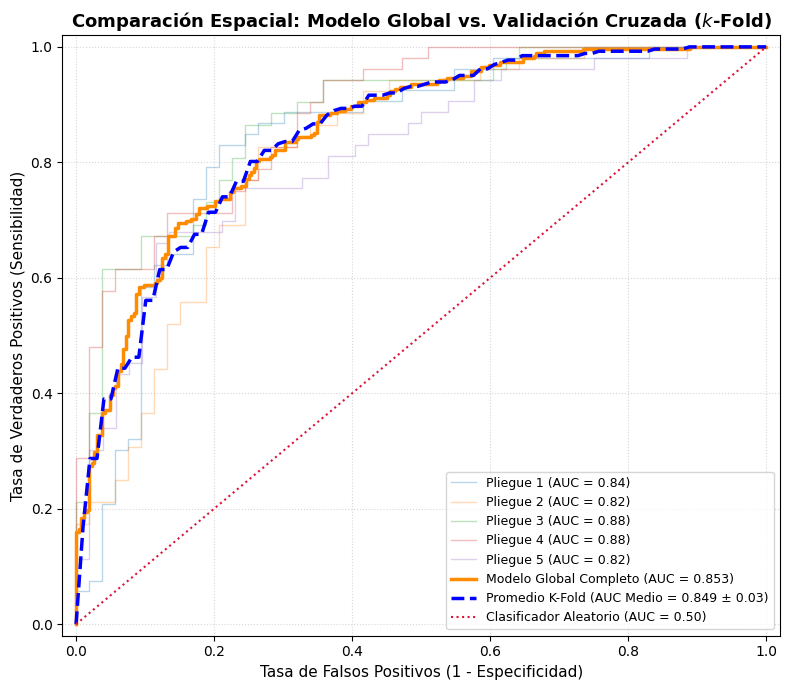

In [19]:
import geopandas as gpd
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score 
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. CONFIGURACIÓN INICIAL Y PREPARACIÓN DE DATOS
# ==============================================================================
COLUMNA_DESLIZAMIENTOS = 'lands_rec'  
covariables = ['elev_mean', 'rel_mean', 'area']

# Crear la variable binaria desliz_alto basada en la mediana
mediana_desliz = gdf[COLUMNA_DESLIZAMIENTOS].median()
gdf['desliz_alto'] = (gdf[COLUMNA_DESLIZAMIENTOS] > mediana_desliz).astype(int)

# Seleccionar las covariables y la variable objetivo
X = gdf[covariables].copy()
y = gdf['desliz_alto']

# Eliminar filas con valores nulos (NaN) para evitar fallos en el ajuste
X = X.dropna()
y = y.loc[X.index]

# Estandarizar las covariables para el modelo global
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=covariables, index=X.index)
X_scaled_const = sm.add_constant(X_scaled)

# ==============================================================================
# 2. MODELO GLOBAL (STATSMODELS) Y PREDICCIONES
# ==============================================================================
modelo = sm.Logit(y, X_scaled_const).fit()

# Generar predicciones globales corregidas
y_probs_global = modelo.predict(X_scaled_const)
y_pred_global = (y_probs_global >= 0.5).astype(int)

# ==============================================================================
# 3. REPORTES EN CONSOLA (MATRIZ Y COEFICIENTES)
# ==============================================================================
cm_global = confusion_matrix(y, y_pred_global)
df_cm = pd.DataFrame(cm_global, index=['Real: Bajo (0)', 'Real: Alto (1)'], 
                             columns=['Predicho: Bajo (0)', 'Predicho: Alto (1)'])
print("\n" + "="*50)
print("MATRIZ DE CONFUSIÓN GLOBAL (Umbral = 0.5)")
print("="*50)
print(df_cm)

print("\n" + "="*80)
print("REPORTE FORMAL: COEFICIENTES Y ODDS RATIOS (IC 95%)")
print("="*80)
df_reporte = pd.DataFrame({'Coeficiente (Beta)': modelo.params, 'p-valor': modelo.pvalues})
int_conf_beta = modelo.conf_int()
df_reporte['IC Beta 2.5%'] = int_conf_beta[0]
df_reporte['IC Beta 97.5%'] = int_conf_beta[1]
df_reporte['Odds Ratio (OR)'] = np.exp(modelo.params)
df_reporte['OR IC 2.5%'] = np.exp(int_conf_beta[0])
df_reporte['OR IC 97.5%'] = np.exp(int_conf_beta[1])
print(df_reporte[['Coeficiente (Beta)', 'p-valor', 'Odds Ratio (OR)', 'OR IC 2.5%', 'OR IC 97.5%']].round(4))

# ==============================================================================
# 4. VALIDACIÓN CRUZADA Y CAPTURA DE CURVAS ROC POR PLIEGUE
# ==============================================================================
# Usamos StratifiedKFold por seguridad y estabilidad con los datos espaciales
conteo_clase_minima = y.value_counts().min()
n_pliegues = 5 if conteo_clase_minima >= 5 else 3

kf = StratifiedKFold(n_splits=n_pliegues, shuffle=True, random_state=42)
modelo_lr = LogisticRegression(penalty=None)
scaler_cv = StandardScaler()

auc_scores = []

# Configuración del gráfico de comparación
fig, ax = plt.subplots(figsize=(8, 7))

# Espacio para interpolar curvas ROC y calcular la curva promedio exacta
mean_fpr = np.linspace(0, 1, 100)
tprs = []

print("\n" + "="*50)
print("EJECUTANDO VALIDACIÓN CRUZADA ESTRATIFICADA")
print("="*50)

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    if len(np.unique(y_test)) < 2:
        print(f"Pliegue {fold}: [SALTADO] Datos insuficientes en el set de prueba.")
        continue
        
    X_train_scaled = scaler_cv.fit_transform(X_train)
    X_test_scaled = scaler_cv.transform(X_test)
    
    modelo_lr.fit(X_train_scaled, y_train)
    y_probs_test = modelo_lr.predict_proba(X_test_scaled)[:, 1]
    
    try:
        auc_fold = roc_auc_score(y_test, y_probs_test)
        auc_scores.append(auc_fold)
        print(f"Pliegue {fold}: AUC-ROC = {auc_fold:.4f}")
        
        # Calcular valores de la curva ROC para el pliegue actual
        fpr_fold, tpr_fold, _ = roc_curve(y_test, y_probs_test)
        # Graficar pliegue individual (línea delgada y sutil)
        ax.plot(fpr_fold, tpr_fold, alpha=0.3, lw=1, label=f'Pliegue {fold} (AUC = {auc_fold:.2f})')
        
        # Interpolar para promediar después
        interp_tpr = np.interp(mean_fpr, fpr_fold, tpr_fold)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        
    except ValueError:
        print(f"Pliegue {fold}: [SALTADO] Error de desbalance.")

auc_media = np.mean(auc_scores)
auc_std = np.std(auc_scores)

print("="*50)
print(f"Media del AUC-ROC en CV: {auc_media:.4f}  |  Desviación Estándar (σ): {auc_std:.4f}")
print("="*50)

# ==============================================================================
# 5. GRAFICAR COMPARACIÓN DE MODELOS (GLOBAL VS. K-FOLD)
# ==============================================================================
# A. Curva ROC del Modelo Global (Ajustado con 100% de los datos)
fpr_global, tpr_global, _ = roc_curve(y, y_probs_global)
auc_global = roc_auc_score(y, y_probs_global)
ax.plot(fpr_global, tpr_global, color='darkorange', lw=2.5, linestyle='-',
        label=f'Modelo Global Completo (AUC = {auc_global:.3f})')

# B. Curva ROC Promedio resultante de la Validación Cruzada
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
ax.plot(mean_fpr, mean_tpr, color='blue', lw=2.5, linestyle='--',
        label=f'Promedio K-Fold (AUC Medio = {auc_media:.3f} ± {auc_std:.2f})')

# C. Línea de Clasificación Aleatoria de Referencia
ax.plot([0, 1], [0, 1], color='crimson', lw=1.5, linestyle=':', label='Clasificador Aleatorio (AUC = 0.50)')

# Ajustes de diseño del gráfico
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_title('Comparación Espacial: Modelo Global vs. Validación Cruzada ($k$-Fold)', fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()